In [1]:
# Explainable machine learning for household electricity demand forecasting.
#
# Dataset  : UCI Individual Household Electric Power Consumption
#            (December 2006 to November 2010, one-minute resolution)
# Target   : Global_active_power (kW)
# Pipeline : XGBoost, LightGBM, CatBoost and Random Forest base learners
#            combined by a constrained convex blend. The Holt-Winters
#            decomposition is retained as an analysis layer only.


In [2]:
# Package installation

import subprocess, sys

_PACKAGES = [
    'pandas>=1.5', 'numpy>=1.23', 'matplotlib>=3.6',
    'seaborn>=0.12', 'scikit-learn>=1.3', 'statsmodels>=0.14',
    'shap>=0.42', 'lime>=0.2', 'scipy>=1.10',
    'xgboost>=1.7', 'lightgbm>=4.0', 'catboost>=1.2', 'joblib>=1.2',
    'arch>=5.3',  # circular block bootstrap for autocorrelated residuals
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q'] + _PACKAGES
)
print('Package installation complete.')


Package installation complete.


In [3]:
# Imports and global configuration

from __future__ import annotations
import gc, warnings, json, time
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, wilcoxon

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import shap
from lime.lime_tabular import LimeTabularExplainer
import joblib


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directory
OUTPUT_DIR = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot style
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi':      110,
    'figure.figsize':  (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size':       10,
})
PALETTE = {
    'primary':   '#1f4e8c',
    'secondary': '#c0392b',
    'accent':    '#27ae60',
    'neutral':   '#7f8c8d',
}

# Figure conventions
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  12,
    'axes.labelsize':  11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'savefig.dpi':     400,
    'pdf.fonttype':    42, 
    'ps.fonttype':     42,
})

def savefig_pub(stem, fig=None, **kwargs):
    """Save a figure as a 400-dpi raster and a vector copy."""
    fig = fig if fig is not None else plt.gcf()
    kwargs.setdefault('bbox_inches', 'tight')
    fig.savefig(OUTPUT_DIR / f'{stem}.png', dpi=300, **kwargs)
    fig.savefig(OUTPUT_DIR / f'{stem}.pdf', **kwargs)

# Descriptive feature labels.


_RAW_VAR_LABELS = {
    'Global_active_power':   'Active power (kW)',
    'Global_reactive_power': 'Reactive power (kVAr)',
    'Voltage':               'Voltage (V)',
    'Global_intensity':      'Current intensity (A)',
    'Sub_metering_1':        'Kitchen sub-meter (Wh)',
    'Sub_metering_2':        'Laundry sub-meter (Wh)',
    'Sub_metering_3':        'Water-heater sub-meter (Wh)',
}

def _dur_label(m):
    """Readable duration for a horizon of m minutes."""
    m = int(m)
    if m % 1440 == 0:
        d = m // 1440
        return '1 day' if d == 1 else f'{d} days'
    if m % 60 == 0:
        h = m // 60
        return '1 hour' if h == 1 else f'{h} hours'
    return '1 minute' if m == 1 else f'{m} minutes'

def pub_label(feat):
    """Descriptive label for an engineered-feature name."""
    import re as _re
    f = str(feat)
    _fixed = {
        'diff_lag1_lag2':        'Load change (1 minute)',
        'diff_lag1_lag60':       'Load change (1 hour)',
        'gap_vs_yesterday':      'Change from previous day',
        'gap_vs_last_week':      'Change from previous week',
        'gap_vs_daily_mean':     'Deviation from daily mean',
        'gap_vs_weekly_mean':    'Deviation from weekly mean',
        'interaction_hour_lag1': 'Recent load by hour of day',
        'hour_sin':   'Hour of day (sine)',
        'hour_cos':   'Hour of day (cosine)',
        'day_sin':    'Day of week (sine)',
        'day_cos':    'Day of week (cosine)',
        'month_sin':  'Month of year (sine)',
        'month_cos':  'Month of year (cosine)',
        'mon_sin':    'Month of year (sine)',
        'mon_cos':    'Month of year (cosine)',
        'is_weekend': 'Weekend indicator',
        'hw_trend':        'Holt-Winters trend',
        'hw_seasonal':     'Holt-Winters seasonal term',
        'hw_residual':     'Holt-Winters residual',
        'hw_log_forecast': 'Holt-Winters forecast',
    }
    if f in _fixed:
        return _fixed[f]
    if f in _RAW_VAR_LABELS:
        return _RAW_VAR_LABELS[f]
    if f.endswith('_was_missing'):
        base = f[:-len('_was_missing')]
        base_lbl = _RAW_VAR_LABELS.get(base, base.replace('_', ' '))
        return f'Imputed reading ({base_lbl.split(" (")[0].lower()})'
    m = _re.search(r'_lag_(\d+)$', f)
    if m:
        return f'Load {_dur_label(int(m.group(1)))} earlier'
    m = _re.search(r'_roll_(mean|std|min|max)_(\d+)$', f)
    if m:
        stat = {'mean': 'Mean load', 'std': 'Standard deviation',
                'min': 'Minimum load', 'max': 'Maximum load'}[m.group(1)]
        return f'{stat} ({_dur_label(int(m.group(2)))})'
    m = _re.search(r'_ewm_(\d+)$', f)
    if m:
        return f'Smoothed load ({_dur_label(int(m.group(1)))})'
    m = _re.search(r'^f(?:ourier_)?([dw])_(sin|cos)_(\d+)$', f)
    if m:
        scope = 'Daily' if m.group(1) == 'd' else 'Weekly'
        trig = 'sine' if m.group(2) == 'sin' else 'cosine'
        return f'{scope} harmonic {m.group(3)} ({trig})'
    m = _re.search(r'hw_res(?:idual)?_lag_?(\d+)$', f)
    if m:
        return f'Holt-Winters residual ({_dur_label(int(m.group(1)))} earlier)'
    return f.replace('_', ' ')

print(f"Environment configured. Random seed: {RANDOM_STATE}")


Environment configured. Random seed: 42


In [4]:
# Data acquisition


import urllib.request, zipfile

DATA_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
DATA_ZIP  = Path('household_power_consumption.zip')
DATA_FILE = Path('household_power_consumption.txt')

if not DATA_FILE.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_ZIP)
    with zipfile.ZipFile(DATA_ZIP, 'r') as z:
        z.extractall('.')
    print('Download complete.')
else:
    print('Dataset already present on disk.')


Dataset already present on disk.


In [5]:
# Parsing and initial data-quality assessment
# The character '?' denotes a missing reading. The Date and Time fields are
# combined into a regular one-minute DatetimeIndex.

df_raw = pd.read_csv(
    DATA_FILE, sep=';', na_values=['?'],
    low_memory=False, dtype=str
)
dt = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S', errors='coerce'
)
df_raw = df_raw.drop(columns=['Date', 'Time'])
df_raw.index = dt
df_raw = df_raw[~df_raw.index.isna()].sort_index()
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw = df_raw.asfreq('1min')  # inserting empty rows for any skipped minutes

NUMERIC_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in NUMERIC_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape          : {df_raw.shape}")
print(f"Date range     : {df_raw.index.min()} to {df_raw.index.max()}")
print(f"Missing values : {df_raw[NUMERIC_COLS].isna().sum().sum():,}")

summary = df_raw[NUMERIC_COLS].describe().T
summary['missing_pct'] = df_raw[NUMERIC_COLS].isna().mean() * 100
print("\n--- Descriptive statistics ---")
print(summary.round(4).to_string())


Shape          : (2075259, 7)
Date range     : 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Missing values : 181,853

--- Descriptive statistics ---
                           count      mean     std      min      25%      50%      75%      max  missing_pct
Global_active_power    2049280.0    1.0916  1.0573    0.076    0.308    0.602    1.528   11.122       1.2518
Global_reactive_power  2049280.0    0.1237  0.1127    0.000    0.048    0.100    0.194    1.390       1.2518
Voltage                2049280.0  240.8399  3.2400  223.200  238.990  241.010  242.890  254.150       1.2518
Global_intensity       2049280.0    4.6278  4.4444    0.200    1.400    2.600    6.400   48.400       1.2518
Sub_metering_1         2049280.0    1.1219  6.1530    0.000    0.000    0.000    0.000   88.000       1.2518
Sub_metering_2         2049280.0    1.2985  5.8220    0.000    0.000    0.000    1.000   80.000       1.2518
Sub_metering_3         2049280.0    6.4584  8.4372    0.000    0.000    1.000   17.000   3

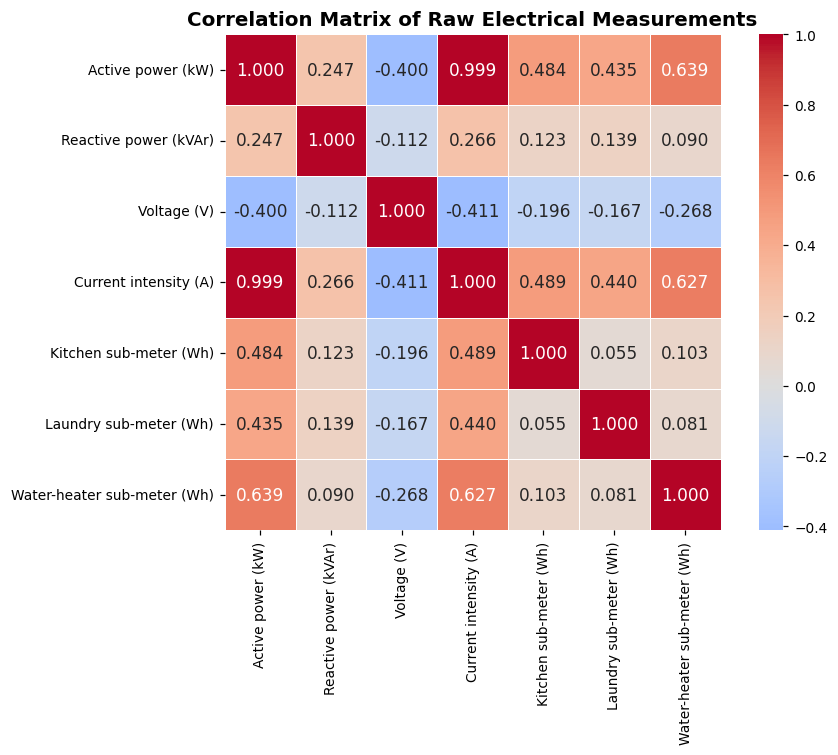

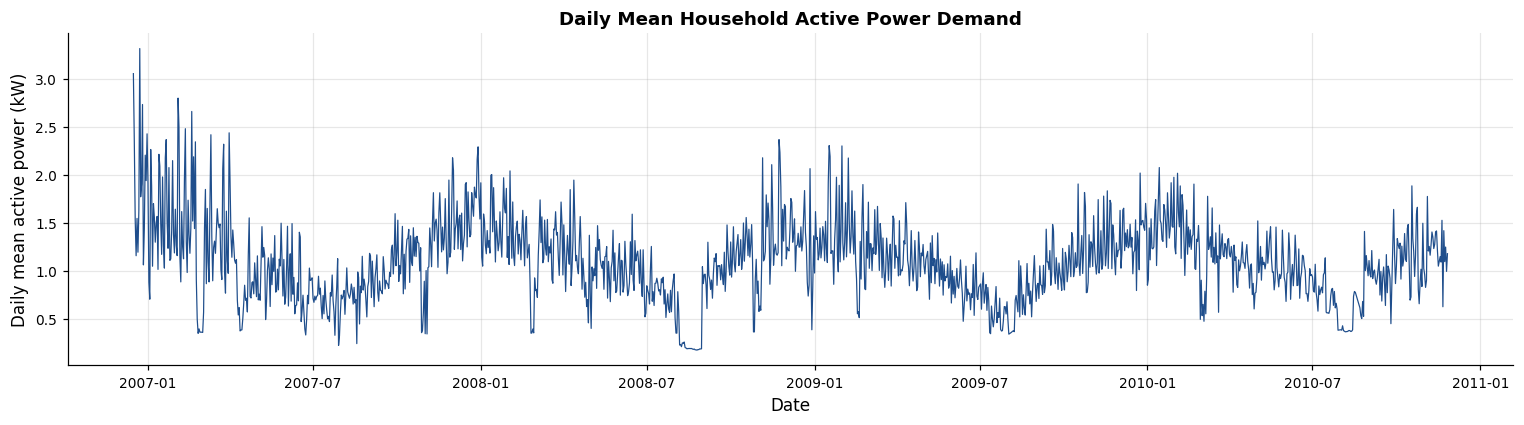


Running ADF on 34,168 hourly observations ...
ADF Statistic : -14.2374
p-value       : 1.5588e-26
  Critical (1%): -3.4305
  Critical (5%): -2.8616
  Critical (10%): -2.5668
Decision      : STATIONARY


1810

In [6]:
# Exploratory data analysis

# (a) Correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
corr  = df_raw[NUMERIC_COLS].corr()
# Descriptive measurement 
short = ['Active power (kW)', 'Reactive power (kVAr)', 'Voltage (V)',
         'Current intensity (A)', 'Kitchen sub-meter (Wh)',
         'Laundry sub-meter (Wh)', 'Water-heater sub-meter (Wh)']
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    xticklabels=short, yticklabels=short, ax=ax
)
ax.set_title('Correlation Matrix of Raw Electrical Measurements',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_pub('eda_correlation_heatmap')
plt.show()

# (b) Daily mean demand series
daily = df_raw['Global_active_power'].resample('D').mean().dropna()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color=PALETTE['primary'])
ax.set_title('Daily Mean Household Active Power Demand', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Daily mean active power (kW)'); ax.grid(alpha=0.3)
plt.tight_layout()
savefig_pub('eda_daily_power')
plt.show()

# (c) Augmented Dickey-Fuller stationarity test on hourly aggregates
series_hourly = df_raw['Global_active_power'].resample('h').mean().dropna()
print(f"\nRunning ADF on {len(series_hourly):,} hourly observations ...")
adf_stat, p_val, used_lag, nobs, crit_vals, _ = adfuller(series_hourly)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_val:.4e}")
for k, v in crit_vals.items():
    print(f"  Critical ({k}): {v:.4f}")
decision = 'STATIONARY' if p_val < 0.05 else 'NON-STATIONARY'
print(f"Decision      : {decision}")
del series_hourly; gc.collect()


In [7]:
# Preprocessing


df = df_raw[NUMERIC_COLS].copy()
for col in NUMERIC_COLS:
    df[f'{col}_was_missing'] = df[col].isna().astype('int8')
    df[col] = df[col].interpolate(method='time')
    df[col] = df[col].ffill().bfill()

for col in NUMERIC_COLS:
    df[col] = df[col].astype('float32')

print(f"Missing after imputation  : {df[NUMERIC_COLS].isna().sum().sum()}")
print(f"DataFrame memory          : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Missing after imputation  : 0
DataFrame memory          : 89.2 MB


In [8]:
# Feature engineering

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df.index.dayofweek >= 5).astype('int8')

CALENDAR_FEATURES = ['hour', 'day_of_week', 'month', 'is_weekend']

for (col, period) in [('hour', 24), ('day_of_week', 7), ('month', 12)]:
    suffix = col.split('_')[0] if '_' in col else col
    df[f'{suffix}_sin'] = np.sin(2*np.pi*df[col]/period).astype('float32')
    df[f'{suffix}_cos'] = np.cos(2*np.pi*df[col]/period).astype('float32')

CYCLICAL_FEATURES = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'mon_sin',  'mon_cos',
    'is_weekend',
]

# Fourier seasonal basis. The ablation study determines whether these
# fourteen additional columns are retained in the model feature set.
K_DAILY  = 4  # harmonics of the 1440-minute daily cycle
K_WEEKLY = 3  # harmonics of the 10080-minute weekly cycle

minute_of_day  = (df.index.hour * 60 + df.index.minute).astype('int32')
minute_of_week = (df.index.dayofweek * 1440 + minute_of_day).astype('int32')

for k in range(1, K_DAILY + 1):
    ang = 2.0 * np.pi * k * minute_of_day / 1440.0
    df[f'fourier_d_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_d_cos_{k}'] = np.cos(ang).astype('float32')

for k in range(1, K_WEEKLY + 1):
    ang = 2.0 * np.pi * k * minute_of_week / 10080.0
    df[f'fourier_w_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_w_cos_{k}'] = np.cos(ang).astype('float32')

FOURIER_FEATURES = (
    [f'fourier_d_sin_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_d_cos_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_w_sin_{k}' for k in range(1, K_WEEKLY + 1)]
    + [f'fourier_w_cos_{k}' for k in range(1, K_WEEKLY + 1)]
)

del minute_of_day, minute_of_week
gc.collect()

print(f"Cyclical features  : {CYCLICAL_FEATURES}")
print(f"Fourier features   : {len(FOURIER_FEATURES)} terms "
      f"(K_daily={K_DAILY}, K_weekly={K_WEEKLY})")
print(f"Total calendar+Fourier : {len(CYCLICAL_FEATURES) + len(FOURIER_FEATURES)}")


Cyclical features  : ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mon_sin', 'mon_cos', 'is_weekend']
Fourier features   : 14 terms (K_daily=4, K_weekly=3)
Total calendar+Fourier : 21


In [9]:
# Feature engineering: lags, rolling statistics, differences, exponentially
# weighted means and an interaction term.


TARGET          = 'Global_active_power'

LAG_STEPS       = [1, 2, 3, 5, 10, 15, 30, 60, 120, 240, 1440]

ROLLING_WINDOWS = [5, 15, 60, 180, 1440]

print(f"Generating {len(LAG_STEPS)} lag features ...")
for lag in LAG_STEPS:
    df[f'{TARGET}_lag_{lag}'] = df[TARGET].shift(lag).astype('float32')

print(f"Generating {len(ROLLING_WINDOWS)*4} rolling statistics "
      f"(mean, std. dev., minimum, maximum over {ROLLING_WINDOWS}) ...")
shifted = df[TARGET].shift(1)
for w in ROLLING_WINDOWS:
    r = shifted.rolling(window=w, min_periods=1)
    df[f'{TARGET}_roll_mean_{w}'] = r.mean().astype('float32')
    df[f'{TARGET}_roll_std_{w}']  = r.std().fillna(0).astype('float32')
    df[f'{TARGET}_roll_min_{w}']  = r.min().astype('float32')
    df[f'{TARGET}_roll_max_{w}']  = r.max().astype('float32')
del shifted

# Difference features
print("Generating difference features ...")
df['diff_lag1_lag2']  = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_2']).astype('float32')
df['diff_lag1_lag60'] = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_60']).astype('float32')

DIFF_FEATURES = ['diff_lag1_lag2', 'diff_lag1_lag60']

LAG_FEATURES     = [f'{TARGET}_lag_{l}' for l in LAG_STEPS]
ROLLING_FEATURES = (
    [f'{TARGET}_roll_{s}_{w}' for w in ROLLING_WINDOWS
     for s in ['mean', 'std', 'min', 'max']]
)


EWM_SPANS = [5, 30, 60, 1440]
print(f"Generating {len(EWM_SPANS)} exponentially weighted means "
      f"(spans={EWM_SPANS}) ...")
for span in EWM_SPANS:
    df[f'{TARGET}_ewm_{span}'] = (
        df[TARGET].shift(1)
        .ewm(span=span, min_periods=1, adjust=False)
        .mean()
        .astype('float32')
    )

EWM_FEATURES = [f'{TARGET}_ewm_{s}' for s in EWM_SPANS]


print("Generating hour-of-day interaction feature ...")
df['interaction_hour_lag1'] = (
    df['hour_sin'] * df[f'{TARGET}_lag_1']
).astype('float32')

INTERACTION_FEATURES = ['interaction_hour_lag1']

gc.collect()
print(f"\nAutoregressive feature counts:")
print(f"  Lags                       : {len(LAG_FEATURES)}")
print(f"  Rolling statistics         : {len(ROLLING_FEATURES)}")
print(f"  Differences                : {len(DIFF_FEATURES)}")
print(f"  Exponentially weighted     : {len(EWM_FEATURES)}")
print(f"  Interaction                : {len(INTERACTION_FEATURES)}")
print(f"  Total                      : {len(LAG_FEATURES)+len(ROLLING_FEATURES)+len(DIFF_FEATURES)+len(EWM_FEATURES)+len(INTERACTION_FEATURES)}")
print(f"  Longest lookback : {max(LAG_STEPS):,} min = {max(LAG_STEPS)/1440:.1f} days")
print(f"  Columns total    : {df.shape[1]}")
print(f"  Memory           : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Generating 11 lag features ...
Generating 20 rolling statistics (mean, std. dev., minimum, maximum over [5, 15, 60, 180, 1440]) ...
Generating difference features ...
Generating 4 exponentially weighted means (spans=[5, 30, 60, 1440]) ...
Generating hour-of-day interaction feature ...

Autoregressive feature counts:
  Lags                       : 11
  Rolling statistics         : 20
  Differences                : 2
  Exponentially weighted     : 4
  Interaction                : 1
  Total                      : 38
  Longest lookback : 1,440 min = 1.0 days
  Columns total    : 76
  Memory           : 738.8 MB


In [10]:
# Holt-Winters decomposition, used as an analysis layer rather than as the
# prediction base. A rolling refit with a 30-day step and an 18-month training
# window yields trend, seasonal and residual components as candidate features.


SEASONAL_PERIODS = 24
REFIT_DAYS       = 30
HISTORY_MONTHS   = 18

series_hourly     = df[TARGET].resample('h').mean().dropna()
series_hourly_log = np.log1p(series_hourly)
N_HOURLY          = len(series_hourly_log)
HW_TRAIN_END      = int(N_HOURLY * 0.70)

hw_train_series  = series_hourly_log.iloc[:HW_TRAIN_END]
hw_future_series = series_hourly_log.iloc[HW_TRAIN_END:]

print(f'HW fit on {len(hw_train_series):,} hourly obs '
      f'({hw_train_series.index.min().date()} to {hw_train_series.index.max().date()})')

hw_model_init = ExponentialSmoothing(
    hw_train_series, trend='add', seasonal='add',
    seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
).fit(optimized=True)

hw_fitted_train_h = pd.Series(hw_model_init.fittedvalues.values, index=hw_train_series.index)
level_h  = pd.Series(hw_model_init.level.values,  index=hw_train_series.index)
season_h = pd.Series(hw_model_init.season.values, index=hw_train_series.index)

# Rolling refits for val+test
refit_starts  = pd.date_range(start=hw_future_series.index[0],
                               end=hw_future_series.index[-1], freq=f'{REFIT_DAYS}D')
forecast_chunks = []
hw_model_train  = hw_model_init

for i, refit_date in enumerate(refit_starts):
    window_end   = refit_date - pd.Timedelta(hours=1)
    window_start = window_end - pd.DateOffset(months=HISTORY_MONTHS)
    train_win = series_hourly_log.loc[
        (series_hourly_log.index >= window_start) &
        (series_hourly_log.index <= window_end)
    ]
    if len(train_win) < SEASONAL_PERIODS * 4:
        train_win = series_hourly_log.loc[series_hourly_log.index <= window_end]
    hz_end = (refit_starts[i+1] - pd.Timedelta(hours=1)
              if i+1 < len(refit_starts) else hw_future_series.index[-1])
    fc_idx = hw_future_series.index[
        (hw_future_series.index >= refit_date) & (hw_future_series.index <= hz_end)
    ]
    if len(fc_idx) == 0:
        continue
    try:
        hw_m = ExponentialSmoothing(
            train_win, trend='add', seasonal='add',
            seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
        ).fit(optimized=True)
        fc = hw_m.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)
        hw_model_train = hw_m
    except Exception as e:
        fc = hw_model_init.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)

hw_log_forecast_h = (
    pd.concat([hw_fitted_train_h] + forecast_chunks)
    .pipe(lambda s: s[~s.index.duplicated(keep='first')])
    .sort_index()
    .reindex(series_hourly_log.index)
    .interpolate(method='time')
)
hw_resid_h = series_hourly_log - hw_log_forecast_h

# Forward-fill to minute level
df['hw_log_forecast'] = hw_log_forecast_h.reindex(df.index, method='ffill').bfill().astype('float32')
df['hw_residual']     = hw_resid_h.reindex(df.index,        method='ffill').bfill().astype('float32')
df['hw_trend']        = level_h.reindex(df.index,           method='ffill').bfill().astype('float32')
df['hw_seasonal']     = season_h.reindex(df.index,          method='ffill').bfill().astype('float32')

HW_FEATURES = ['hw_trend', 'hw_seasonal', 'hw_residual'] \


FITTED_HW_PARAMS = dict(
    model=hw_model_train, seasonal_periods=SEASONAL_PERIODS,
    refit_days=REFIT_DAYS, history_months=HISTORY_MONTHS,
)

_r2_hw = float(1 - np.nansum((series_hourly_log.values - hw_log_forecast_h.values)**2)
                  / np.nansum((series_hourly_log.values - series_hourly_log.mean())**2))
print(f'Rolling Holt-Winters refit complete: {len(refit_starts)} refits')
print(f'Hourly R² in log space   : {_r2_hw:.4f}   (analysis only)')
print(f'\nRole of the Holt-Winters components:')
print(f'  hw_log_forecast : excluded from the feature set')
print(f'  hw_trend        : ablation candidate')
print(f'  hw_seasonal     : ablation candidate')
print(f'  hw_residual     : ablation candidate')

del series_hourly, series_hourly_log, hw_future_series
gc.collect()


HW fit on 24,212 hourly obs (2006-12-16 to 2009-09-20)
Rolling Holt-Winters refit complete: 15 refits
Hourly R² in log space   : 0.2982   (analysis only)

Role of the Holt-Winters components:
  hw_log_forecast : excluded from the feature set
  hw_trend        : ablation candidate
  hw_seasonal     : ablation candidate
  hw_residual     : ablation candidate


0

In [11]:
# Feature engineering: memory-gap features


required = [
    f'{TARGET}_lag_1', f'{TARGET}_lag_1440',
    f'{TARGET}_roll_mean_1440',
]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing upstream features: {missing}"

l1    = df[f'{TARGET}_lag_1'].to_numpy(dtype='float32')
l1440 = df[f'{TARGET}_lag_1440'].to_numpy(dtype='float32')
rm1440 = df[f'{TARGET}_roll_mean_1440'].to_numpy(dtype='float32')

df['gap_vs_yesterday']  = (l1 - l1440 ).astype('float32')
df['gap_vs_daily_mean'] = (l1 - rm1440).astype('float32')

GAP_FEATURES = ['gap_vs_yesterday', 'gap_vs_daily_mean']

del l1, l1440, rm1440
gc.collect()

print(f"Memory-gap features : {GAP_FEATURES}")
print(f"Difference features : {['diff_lag1_lag2', 'diff_lag1_lag60']}")


Memory-gap features : ['gap_vs_yesterday', 'gap_vs_daily_mean']
Difference features : ['diff_lag1_lag2', 'diff_lag1_lag60']


In [12]:
# Chronological split and feature selection
# The sample is divided 70/15/15 in time order, so that no model is trained on
# observations later than those it is evaluated on.

df = df.dropna().copy()

ALWAYS_EXCLUDE = [
    TARGET,
    'Global_intensity',
    'Voltage',
    'Global_reactive_power',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'hw_log_forecast',  # analysis layer only
    # The integer calendar columns are superseded by their cyclical encodings.
    'hour', 'day_of_week', 'month',
]

FEATURE_COLS_FULL = [c for c in df.columns if c not in ALWAYS_EXCLUDE]

# Feature families
_fcset = set(FEATURE_COLS_FULL)
FAM_LAG      = [c for c in LAG_FEATURES     if c in _fcset]
FAM_ROLL     = [c for c in ROLLING_FEATURES if c in _fcset]
FAM_DIFF     = [c for c in DIFF_FEATURES    if c in _fcset]
FAM_CYCLICAL = [c for c in CYCLICAL_FEATURES if c in _fcset]
FAM_FOURIER  = [c for c in FOURIER_FEATURES  if c in _fcset]
FAM_GAP      = [c for c in GAP_FEATURES      if c in _fcset]
FAM_HW       = [c for c in HW_FEATURES       if c in _fcset]
FAM_EWM      = [c for c in EWM_FEATURES       if c in _fcset]
FAM_INTERACT = [c for c in INTERACTION_FEATURES if c in _fcset]


PRUNED_FAMILIES = FAM_HW
FEATURE_COLS = [c for c in FEATURE_COLS_FULL if c not in PRUNED_FAMILIES]

N         = len(df)
TRAIN_END = int(N * 0.70)
VAL_END   = int(N * 0.85)

train_df = df.iloc[:TRAIN_END]
val_df   = df.iloc[TRAIN_END:VAL_END]
test_df  = df.iloc[VAL_END:]

print(f'Training   : {len(train_df):>8,} rows  '
      f'({train_df.index.min().date()} to {train_df.index.max().date()})')
print(f'Validation : {len(val_df):>8,} rows  '
      f'({val_df.index.min().date()} to {val_df.index.max().date()})')
print(f'Test       : {len(test_df):>8,} rows  '
      f'({test_df.index.min().date()} to {test_df.index.max().date()})')
print(f'\nFeature families (full candidate set = {len(FEATURE_COLS_FULL)}):')
print(f'  Lags         : {len(FAM_LAG)}')
print(f'  Rolling      : {len(FAM_ROLL)}')
print(f'  Differences  : {len(FAM_DIFF)}')
print(f'  Cyclical     : {len(FAM_CYCLICAL)}')
print(f'  Fourier      : {len(FAM_FOURIER)}')
print(f'  Gap          : {len(FAM_GAP)}')
print(f'  Smoothed     : {len(FAM_EWM)}')
print(f'  Interaction  : {len(FAM_INTERACT)}')
print(f'  Holt-Winters : {len(FAM_HW)}  (removed on ablation evidence)')
print(f'\nModel feature set : {len(FEATURE_COLS)} columns')


Training   : 1,451,673 rows  (2006-12-17 to 2009-09-20)
Validation :  311,073 rows  (2009-09-20 to 2010-04-24)
Test       :  311,073 rows  (2010-04-24 to 2010-11-26)

Feature families (full candidate set = 71):
  Lags         : 11
  Rolling      : 20
  Differences  : 2
  Cyclical     : 5
  Fourier      : 14
  Gap          : 2
  Smoothed     : 4
  Interaction  : 1
  Holt-Winters : 3  (removed on ablation evidence)

Model feature set : 68 columns


In [13]:
# Standardisation

# Reduced model feature set
scaler      = StandardScaler()
X_train     = scaler.fit_transform(train_df[FEATURE_COLS]).astype('float32')
X_val       = scaler.transform(val_df[FEATURE_COLS]).astype('float32')
X_test      = scaler.transform(test_df[FEATURE_COLS]).astype('float32')

y_train     = train_df[TARGET].to_numpy(dtype='float32')
y_val       = val_df[TARGET].to_numpy(dtype='float32')
y_test      = test_df[TARGET].to_numpy(dtype='float32')

X_train_df  = pd.DataFrame(X_train, columns=FEATURE_COLS, index=train_df.index)
X_val_df    = pd.DataFrame(X_val,   columns=FEATURE_COLS, index=val_df.index)
X_test_df   = pd.DataFrame(X_test,  columns=FEATURE_COLS, index=test_df.index)

# Full candidate set, including the Holt-Winters columns
scaler_full     = StandardScaler()
X_train_full_df = pd.DataFrame(
    scaler_full.fit_transform(train_df[FEATURE_COLS_FULL]).astype('float32'),
    columns=FEATURE_COLS_FULL, index=train_df.index)
X_val_full_df   = pd.DataFrame(
    scaler_full.transform(val_df[FEATURE_COLS_FULL]).astype('float32'),
    columns=FEATURE_COLS_FULL, index=val_df.index)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}   (pruned model set)")
print(f"X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"X_test  : {X_test.shape}  dtype={X_test.dtype}")
print(f"Ablation set : {X_train_full_df.shape[1]} columns (Holt-Winters included)")
print(f"Arrays  : {(X_train.nbytes+X_val.nbytes+X_test.nbytes)/1e6:.0f} MB total")
gc.collect()


X_train : (1451673, 68)  dtype=float32   (pruned model set)
X_val   : (311073, 68)  dtype=float32
X_test  : (311073, 68)  dtype=float32
Ablation set : 71 columns (Holt-Winters included)
Arrays  : 564 MB total


0

In [14]:
# Evaluation utilities
# MAE, RMSE, R2, MAPE, sMAPE, MASE and directional accuracy

def mase(y_true, y_pred, y_train, seasonal_period=1440):
    """

    seasonal_period : steps per day of the evaluated series
                      (1440 = 1-min, 288 = 5-min, 144 = 10-min, 24 = hourly).
    """
    naive_errors = np.abs(y_train[seasonal_period:] - y_train[:-seasonal_period])
    mae_naive = naive_errors.mean()
    if mae_naive == 0:
        return np.nan
    return float(mean_absolute_error(y_true, y_pred) / mae_naive)

def directional_accuracy(y_true, y_pred):
    
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)
    return float(np.mean(np.sign(dy_true) == np.sign(dy_pred)))

def block_bootstrap_ci(
    y_true, y_pred,
    metric_fn,
    n_boot=500,
    block_size=1440,
    alpha=0.05,
    rng_seed=42,
):
    
    try:
        from arch.bootstrap import CircularBlockBootstrap
        bs = CircularBlockBootstrap(block_size=block_size,
                                    x=np.column_stack([y_true, y_pred]),
                                    seed=rng_seed)
        def _metric(x_resamp):
            yt = x_resamp[:, 0].squeeze()
            yp = x_resamp[:, 1].squeeze()
            return metric_fn(yt, yp)
        ci = bs.conf_int(_metric, reps=n_boot, method='percentile',
                         size=1 - alpha)
        return float(ci[0][0]), float(ci[1][0])
    except Exception:
        # Fallback implementation, used when the `arch` package is unavailable.
        rng = np.random.default_rng(rng_seed)
        n = len(y_true)
        n_blocks = int(np.ceil(n / block_size))
        vals = []
        for _ in range(n_boot):
            starts = rng.integers(0, n, size=n_blocks)
            idx = np.concatenate([
                np.arange(s, s + block_size) % n for s in starts
            ])[:n]
            vals.append(metric_fn(y_true[idx], y_pred[idx]))
        lo = float(np.percentile(vals, 100 * alpha / 2))
        hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))
        return lo, hi

def eval_metrics(
    y_true, y_pred,
    y_train_ref=None,
    seasonal_period=1440,  # daily seasonal naive at one-minute resolution
    compute_ci=False,
    ci_block_size=1440,
):
    y_true = np.asarray(y_true, dtype='float64')
    y_pred = np.asarray(y_pred, dtype='float64')

    mae  = float(mean_absolute_error(y_true, y_pred))
    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2   = float(r2_score(y_true, y_pred))

    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

    smape = float(np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100)

    result = dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2,
                  MAPE=mape, sMAPE=smape,
                  DA=directional_accuracy(y_true, y_pred))

    if y_train_ref is not None:
        result['MASE'] = mase(y_true, y_pred, y_train_ref, seasonal_period)

    if compute_ci:
        rmse_lo, rmse_hi = block_bootstrap_ci(
            y_true, y_pred,
            lambda a, b: float(np.sqrt(mean_squared_error(a, b))),
            block_size=ci_block_size,
        )
        r2_lo, r2_hi = block_bootstrap_ci(
            y_true, y_pred, r2_score, block_size=ci_block_size,
        )
        result['RMSE_CI'] = (rmse_lo, rmse_hi)
        result['R2_CI']   = (r2_lo,   r2_hi)

    return result

results = {}
print('Evaluation utilities defined.')


Evaluation utilities defined.


In [15]:
# Reference models
# Linear regression, LASSO, k-nearest neighbours, a random forest, a standalone
# gradient-boosted tree ensemble and an ARIMA model. The ARIMA model is fitted
# to hourly aggregates, so its errors are not directly comparable with those of
# the one-minute models and are reported separately.

tscv3 = TimeSeriesSplit(n_splits=3)

y_pred_persist = df[TARGET].shift(1).loc[test_df.index].to_numpy(dtype='float32')
results['Persistence'] = {
    'y_pred':  y_pred_persist,
    'metrics': eval_metrics(y_test, y_pred_persist, y_train_ref=y_train,
                            seasonal_period=1440),
}
print('Persistence (naive):', {k: round(v, 4) for k, v in results['Persistence']['metrics'].items()
                               if k not in ('RMSE_CI','R2_CI')})

# Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['LinearRegression'] = {
    'y_pred':  y_pred_lr,
    'metrics': eval_metrics(y_test, y_pred_lr, y_train_ref=y_train)
}
print('LinearRegression:', {k: round(v, 4) for k, v in results['LinearRegression']['metrics'].items()
                             if k not in ('RMSE_CI','R2_CI')})

# LASSO
lasso_gs = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=10_000),
    {'alpha': [1e-4, 1e-3, 1e-2, 0.1, 1.0]},
    scoring='neg_root_mean_squared_error', cv=tscv3, n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
y_pred_lasso = lasso_gs.predict(X_test)
results['LASSO'] = {
    'y_pred':  y_pred_lasso,
    'metrics': eval_metrics(y_test, y_pred_lasso, y_train_ref=y_train)
}
print('LASSO best alpha:', lasso_gs.best_params_)

print('LASSO:', {k: round(v, 4) for k, v in results['LASSO']['metrics'].items()
                 if k not in ('RMSE_CI','R2_CI')})

#KNN
KNN_TRAIN_SIZE = 30_000
knn_X_sub = X_train[-KNN_TRAIN_SIZE:]
knn_y_sub = y_train[-KNN_TRAIN_SIZE:]
knn_gs = GridSearchCV(
    KNeighborsRegressor(algorithm='ball_tree', leaf_size=40),
    {'n_neighbors': [3, 5, 7, 9]},
    scoring='neg_root_mean_squared_error', cv=tscv3, n_jobs=-1
)
knn_gs.fit(knn_X_sub, knn_y_sub)
y_pred_knn = knn_gs.predict(X_test)
results['KNN'] = {
    'y_pred':  y_pred_knn,
    'metrics': eval_metrics(y_test, y_pred_knn, y_train_ref=y_train)
}
print('KNN best k:', knn_gs.best_params_, '  (chronological tail subsample)')
print('KNN:', {k: round(v, 4) for k, v in results['KNN']['metrics'].items()
               if k not in ('RMSE_CI','R2_CI')})
del knn_X_sub, knn_y_sub; gc.collect()

# Random forest
rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, max_samples=0.5,
    max_features='sqrt', min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['RandomForest'] = {
    'y_pred':  y_pred_rf,
    'metrics': eval_metrics(y_test, y_pred_rf, y_train_ref=y_train)
}
print('RandomForest:', {k: round(v, 4) for k, v in results['RandomForest']['metrics'].items()
                        if k not in ('RMSE_CI','R2_CI')})

# Standalone gradient-boosted trees

xgb_base = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method='hist', objective='reg:squarederror',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)
results['XGBoost'] = {
    'y_pred':  y_pred_xgb,
    'metrics': eval_metrics(y_test, y_pred_xgb, y_train_ref=y_train)
}
print('XGBoost:', {k: round(v, 4) for k, v in results['XGBoost']['metrics'].items()
                   if k not in ('RMSE_CI','R2_CI')})

# ARIMA, fitted to hourly aggregates.

print('\nARIMA is fitted to hourly aggregates. Its errors are reported')
print('separately and are not comparable with the one-minute models.')
h_train = train_df[TARGET].resample('h').mean().dropna()
h_test  = test_df[TARGET].resample('h').mean().dropna()
arima_fit = ARIMA(h_train, order=(2, 1, 2)).fit()
arima_fc  = np.asarray(arima_fit.forecast(steps=len(h_test)))
n_arima   = min(len(h_test), len(arima_fc))
results['ARIMA'] = {
    'y_pred':        arima_fc[:n_arima],
    'y_true_hourly': h_test.to_numpy()[:n_arima],
    'metrics':       eval_metrics(h_test.to_numpy()[:n_arima], arima_fc[:n_arima]),
    'granularity_note': 'hourly resolution; not comparable with the one-minute models',
}
print('ARIMA (hourly):', {k: round(v, 4) for k, v in results['ARIMA']['metrics'].items()
                          if k not in ('RMSE_CI','R2_CI')})
del h_train, h_test; gc.collect()


Persistence (naive): {'MAE': 0.0694, 'MSE': 0.0471, 'RMSE': 0.217, 'R2': 0.9351, 'MAPE': 7.5346, 'sMAPE': 6.7796, 'DA': 0.5114, 'MASE': 0.0858}
LinearRegression: {'MAE': 0.0845, 'MSE': 0.0458, 'RMSE': 0.214, 'R2': 0.9369, 'MAPE': 10.4516, 'sMAPE': 9.4947, 'DA': 0.4504, 'MASE': 0.1044}
LASSO best alpha: {'alpha': 0.0001}
LASSO: {'MAE': 0.0843, 'MSE': 0.0458, 'RMSE': 0.214, 'R2': 0.9369, 'MAPE': 10.441, 'sMAPE': 9.4809, 'DA': 0.4521, 'MASE': 0.1042}
KNN best k: {'n_neighbors': 9}   (chronological tail subsample)
KNN: {'MAE': 0.2255, 'MSE': 0.1179, 'RMSE': 0.3434, 'R2': 0.8376, 'MAPE': 32.7753, 'sMAPE': 29.9972, 'DA': 0.3812, 'MASE': 0.2786}
RandomForest: {'MAE': 0.0771, 'MSE': 0.0423, 'RMSE': 0.2056, 'R2': 0.9417, 'MAPE': 8.9676, 'sMAPE': 8.275, 'DA': 0.4406, 'MASE': 0.0953}
XGBoost: {'MAE': 0.0743, 'MSE': 0.041, 'RMSE': 0.2025, 'R2': 0.9435, 'MAPE': 8.2343, 'sMAPE': 7.7017, 'DA': 0.4452, 'MASE': 0.0918}

ARIMA is fitted to hourly aggregates. Its errors are reported
separately and are no

76

In [16]:
# Proposed model: heterogeneous stacked ensemble
# The base learners are XGBoost, LightGBM and CatBoost, each with
# hyperparameters selected by Bayesian optimisation, together with a random
# forest. They are combined by a constrained convex blend obtained from
# non-negative least squares and projected onto the unit simplex. The combiner
# is selected on the validation split from among the individual base learners,
# their equal-weight average, and blends fitted to out-of-fold and to
# validation predictions. Because the combination is linear and convex, the
# SHAP decomposition of the ensemble is exact. The model is trained
# directly on the raw target.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.base import clone
from scipy.optimize import nnls as _nnls

HPO_SIZE   = 200_000  
VAL_FRAC   = 0.15     
N_TRIALS   = 35       # optimisation trials per base learner

X_hpo   = X_train[-HPO_SIZE:]
y_hpo   = y_train[-HPO_SIZE:]
hpo_val = int(len(X_hpo) * (1 - VAL_FRAC))
X_hv, y_hv = X_hpo[:hpo_val], y_hpo[:hpo_val]
X_he, y_he = X_hpo[hpo_val:], y_hpo[hpo_val:]

print(f"Tuning subsample : {len(X_hpo):,} rows (evaluation split at {hpo_val:,})")

print(f"\n[1/3] Hyperparameter search, XGBoost ({N_TRIALS} trials) ...")
t0 = time.time()

def _xgb_objective(trial):
    params = dict(
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        n_estimators     = 3000,
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        max_depth        = trial.suggest_int('max_depth', 4, 10),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 2.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
        gamma            = trial.suggest_float('gamma', 0.0, 1.0),
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        early_stopping_rounds = 75,
        eval_metric      = 'rmse',
    )
    m = XGBRegressor(**params)
    m.fit(X_hv, y_hv, eval_set=[(X_he, y_he)], verbose=False)
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_xgb = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(_xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
best_xgb_params.update(dict(
    objective='reg:squarederror', tree_method='hist',
    n_estimators=3000, random_state=RANDOM_STATE, n_jobs=-1,
    early_stopping_rounds=75, eval_metric='rmse',
))
xgb_best = XGBRegressor(**best_xgb_params)
xgb_best.fit(X_hv, y_hv, eval_set=[(X_he, y_he)], verbose=False)
print(f"   done {time.time()-t0:.0f}s  best_iter={xgb_best.best_iteration}  "
      f"val_RMSE={study_xgb.best_value:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_xgb.best_params.items()} }")

print(f"\n[2/3] Hyperparameter search, LightGBM ({N_TRIALS} trials) ...")
t0 = time.time()

def _lgbm_objective(trial):
    params = dict(
        objective         = 'regression',
        n_estimators      = 3000,
        learning_rate     = trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        num_leaves        = trial.suggest_categorical('num_leaves', [63, 127, 255]),
        max_depth         = trial.suggest_categorical('max_depth', [-1, 8, 10, 12]),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 80),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.6, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.6, 1.0),
        bagging_freq      = 5,
        lambda_l1         = trial.suggest_float('lambda_l1', 1e-8, 2.0, log=True),
        lambda_l2         = trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1,
    )
    m = LGBMRegressor(**params)
    m.fit(X_hv, y_hv,
          eval_set=[(X_he, y_he)],
          callbacks=[lightgbm.early_stopping(75, verbose=False),
                     lightgbm.log_evaluation(-1)])
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_lgbm = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(_lgbm_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update(dict(
    objective='regression', n_estimators=3000, bagging_freq=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
))
lgbm_best = LGBMRegressor(**best_lgbm_params)
lgbm_best.fit(X_hv, y_hv,
              eval_set=[(X_he, y_he)],
              callbacks=[lightgbm.early_stopping(75, verbose=False),
                         lightgbm.log_evaluation(-1)])
print(f"   done {time.time()-t0:.0f}s  best_iter={lgbm_best.best_iteration_}  "
      f"val_RMSE={study_lgbm.best_value:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_lgbm.best_params.items()} }")

print(f"\n[3/3] Hyperparameter search, CatBoost ({N_TRIALS} trials) ...")
t0 = time.time()
from catboost import Pool as _Pool

def _cb_objective(trial):
    params = dict(
        iterations          = 3000,
        learning_rate       = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        depth               = trial.suggest_int('depth', 5, 10),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 2.0),
        loss_function       = 'RMSE',
        eval_metric         = 'RMSE',
        random_seed         = RANDOM_STATE,
        task_type           = "GPU",
        devices             = "0",
        verbose             = False,
        allow_writing_files = False,
    )
    m = CatBoostRegressor(**params)
    m.fit(_Pool(X_hv, y_hv), eval_set=_Pool(X_he, y_he),
          early_stopping_rounds=75)
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_cb = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(_cb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_cb_params = study_cb.best_params
best_cb_params.update(dict(
    iterations=3000, loss_function='RMSE', eval_metric='RMSE',
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
))
catboost_best = CatBoostRegressor(**best_cb_params)
catboost_best.fit(_Pool(X_hv, y_hv), eval_set=_Pool(X_he, y_he),
                  early_stopping_rounds=75)
cb_val_rmse = float(np.sqrt(np.mean((catboost_best.predict(X_he) - y_he)**2)))
print(f"   done {time.time()-t0:.0f}s  best_iter={catboost_best.best_iteration_}  "
      f"val_RMSE={cb_val_rmse:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_cb.best_params.items()} }")
del X_hv, X_he, y_hv, y_he, X_hpo, y_hpo
gc.collect()

rf_base_learner = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=3,
    max_features=0.5, max_samples=0.5,
    random_state=RANDOM_STATE, n_jobs=-1,
)

class NNLSBlend:

    def __init__(self, weights=None):
        self.coef_ = None if weights is None else np.asarray(weights, dtype='float64')

    def fit(self, P, y):
        P = np.asarray(P, dtype='float64'); y = np.asarray(y, dtype='float64')
        w, _ = _nnls(P, y)
        if not np.isfinite(w).all() or w.sum() <= 0:
            w = np.ones(P.shape[1])
        self.coef_ = w / w.sum()
        return self

    def get_params(self, deep=True):
        return {'weights': self.coef_}

    def set_params(self, **p):
        if 'weights' in p:
            self.coef_ = (None if p['weights'] is None
                          else np.asarray(p['weights'], dtype='float64'))
        return self

    def predict(self, P):
        return np.asarray(P, dtype='float64') @ self.coef_

class TemporalStackingRegressor:
    """Temporal stacking with a forward-chaining out-of-fold scheme.
    """
    def __init__(self, estimators, final_estimator, n_splits=4):
        self.estimators      = estimators
        self.final_estimator = final_estimator
        self.n_splits        = n_splits

    @staticmethod
    def _fit_one(e, X_tr, y_tr, X_es, y_es):
        """Fit a single base learner under its own early-stopping protocol."""
        if isinstance(e, LGBMRegressor):
            e.fit(X_tr, y_tr, eval_set=[(X_es, y_es)],
                  callbacks=[lightgbm.early_stopping(50, verbose=False),
                             lightgbm.log_evaluation(-1)])
        elif isinstance(e, CatBoostRegressor):
            e.fit(X_tr, y_tr, eval_set=(X_es, y_es),
                  early_stopping_rounds=50, verbose=False)
        elif isinstance(e, XGBRegressor):
            e.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
        else:  # estimators without early stopping are fitted to all rows
            e.fit(np.vstack([X_tr, X_es]), np.concatenate([y_tr, y_es]))
        return e

    def _forward_chain_oof(self, X, y):
        n         = len(X)
        fold_size = n // (self.n_splits + 1)
        oof       = np.full((n, len(self.estimators)), np.nan, dtype='float64')
        for k in range(1, self.n_splits + 1):
            tr_end = k * fold_size
            va_end = (k+1)*fold_size if k < self.n_splits else n
            es_cut = int(tr_end * 0.9)
            for j, (name, est) in enumerate(self.estimators):
                e = self._fit_one(clone(est),
                                  X[:es_cut], y[:es_cut],
                                  X[es_cut:tr_end], y[es_cut:tr_end])
                oof[tr_end:va_end, j] = e.predict(X[tr_end:va_end])
            print(f"   OOF block {k}/{self.n_splits}  "
                  f"(train={tr_end:,}  oof={va_end-tr_end:,})")
        mask = ~np.isnan(oof).any(axis=1)
        return oof[mask], y[mask]

    def fit(self, X, y):
        X = np.asarray(X); y = np.asarray(y)
        oof_X, oof_y = self._forward_chain_oof(X, y)
        self.final_estimator_ = clone(self.final_estimator).fit(oof_X, oof_y)
        self.named_estimators_ = {}
        vsp = int(len(X) * 0.9)
        for name, est in self.estimators:
            print(f"   Refitting {name} on full train ...")
            self.named_estimators_[name] = self._fit_one(
                clone(est), X[:vsp], y[:vsp], X[vsp:], y[vsp:])
        from sklearn.metrics import r2_score as _r2
        self.oof_base_r2_ = {
            self.estimators[j][0]: _r2(oof_y, oof_X[:, j])
            for j in range(len(self.estimators))
        }
        return self

    def _base_matrix(self, X):
        return np.column_stack([
            self.named_estimators_[name].predict(np.asarray(X))
            for name, _ in self.estimators
        ])

    def predict(self, X):
        # Convex blend of the base-learner predictions, in the raw target space
        return self.final_estimator_.predict(
            self._base_matrix(X)).astype('float32')


print("\nFitting the stacked ensemble ...")
FINAL_MODEL = TemporalStackingRegressor(
    estimators=[
        ('xgb',      xgb_best),
        ('lgbm',     lgbm_best),
        ('catboost', catboost_best),
        ('rf',       rf_base_learner),
    ],
    final_estimator=NNLSBlend(),
    n_splits=4,
)
t0 = time.time()
FINAL_MODEL.fit(X_train, y_train)
print(f"\nStacking fit complete in {time.time()-t0:.0f}s")

_names = [n for n, _ in FINAL_MODEL.estimators]
print("OOF-NNLS convex weights :")
for _n, _w in zip(_names, FINAL_MODEL.final_estimator_.coef_):
    print(f"  {_n:<10}: {_w:.4f}")
print("OOF R² : " + "  ".join(
    f"{k}={v:.4f}" for k, v in FINAL_MODEL.oof_base_r2_.items()))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, 'float64')
                                  - np.asarray(b, 'float64'))**2)))

P_val = FINAL_MODEL._base_matrix(X_val)
combiner_candidates = {}
for j, nm in enumerate(_names):
    w = np.zeros(len(_names)); w[j] = 1.0
    combiner_candidates[f'single:{nm}'] = w
combiner_candidates['equal-weight'] = np.ones(len(_names)) / len(_names)
combiner_candidates['oof-nnls']     = FINAL_MODEL.final_estimator_.coef_.copy()
combiner_candidates['val-nnls']     = NNLSBlend().fit(P_val, y_val).coef_

print("\n--- Combiner selection on the validation split ---")
_sel = {k: _rmse(y_val, P_val @ w) for k, w in combiner_candidates.items()}
SELECTED_COMBINER = min(_sel, key=_sel.get)
for k, v in sorted(_sel.items(), key=lambda kv: kv[1]):
    mark = '   [selected]' if k == SELECTED_COMBINER else ''
    print(f"  {k:<16} validation RMSE = {v:.5f}{mark}")
FINAL_MODEL.final_estimator_ = NNLSBlend(
    weights=combiner_candidates[SELECTED_COMBINER])
print(f"\nFinal combiner '{SELECTED_COMBINER}' weights : "
      f"{dict(zip(_names, np.round(FINAL_MODEL.final_estimator_.coef_, 4)))}")

# Single base learner used for the LIME and permutation-importance analyses.
SHAP_MODEL = FINAL_MODEL.named_estimators_['xgb']

# Final prediction. The test split is used exactly once.
y_pred_val = np.maximum(FINAL_MODEL.predict(X_val), 0.0)
y_pred_hw  = np.maximum(FINAL_MODEL.predict(X_test), 0.0)

val_metrics  = eval_metrics(y_val,  y_pred_val, y_train_ref=y_train, compute_ci=False)
test_metrics = eval_metrics(y_test, y_pred_hw,  y_train_ref=y_train, compute_ci=True)

PROPOSED_KEY = 'HybridStack (Proposed)'
results[PROPOSED_KEY] = {
    'y_pred':      y_pred_hw,
    'y_pred_val':  y_pred_val,
    'val_metrics': val_metrics,
    'metrics':     test_metrics,
}
results['RawStack']         = results[PROPOSED_KEY]
results['HW+Stack+Fourier'] = results[PROPOSED_KEY]
ALIAS_KEYS = {'RawStack', 'HW+Stack+Fourier'}

print("\n--- Individual base learners against the blend (test split) ---")
P_test = FINAL_MODEL._base_matrix(X_test)
for j, nm in enumerate(_names):
    yb = np.maximum(P_test[:, j], 0.0)
    mb = eval_metrics(y_test, yb, y_train_ref=y_train, compute_ci=False)
    print(f"  {nm:<9}: R²={mb['R2']:.5f}  RMSE={mb['RMSE']:.5f}  MAE={mb['MAE']:.5f}")
print(f"  Blend    : R²={test_metrics['R2']:.5f}  "
      f"RMSE={test_metrics['RMSE']:.5f}  MAE={test_metrics['MAE']:.5f}  (proposed)")


print("\n--- Comparison of the two gradient-boosted configurations ---")
print("  Standalone reference:")

print(f"    hyperparameters : tuned ({ {k: (round(v, 4) if isinstance(v, float) else v) for k, v in study_xgb.best_params.items()} })")
print(f"    training        : early-stopped refit on a 90/10 chronological split")
print(f"                      (best iteration = {FINAL_MODEL.named_estimators_['xgb'].best_iteration})")


print("\n--- Test metrics ---")
print({k: round(v,5) for k,v in test_metrics.items()
       if k not in ('RMSE_CI','R2_CI')})
if 'RMSE_CI' in test_metrics:
    print(f"RMSE 95% CI : {test_metrics['RMSE_CI']}")
    print(f"R²   95% CI : {test_metrics['R2_CI']}")

joblib.dump({
    'base_learners':   FINAL_MODEL.named_estimators_,
    # The combiner is stored as plain weights rather than as a class instance,
    # so that the saved model can be loaded in a session that does not define
    # the notebook classes.
    'meta_weights':    dict(zip(_names, FINAL_MODEL.final_estimator_.coef_)),
    'selected_combiner': SELECTED_COMBINER,
    'estimator_order': _names,
    'scaler':          scaler,
    'feature_cols':    FEATURE_COLS,
    'architecture':    'convex_blend_stacking',
}, 'model.pkl')
print("\nModel written to model.pkl")
gc.collect()


Tuning subsample : 200,000 rows (evaluation split at 170,000)

[1/3] Hyperparameter search, XGBoost (35 trials) ...
   done 44s  best_iter=153  val_RMSE=0.23711
   best params: {'learning_rate': 0.0573, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.7849, 'colsample_bytree': 0.9096, 'reg_alpha': 1.1736, 'reg_lambda': 0.7908, 'gamma': 0.8914}

[2/3] Hyperparameter search, LightGBM (35 trials) ...
   done 56s  best_iter=195  val_RMSE=0.23604
   best params: {'learning_rate': 0.0358, 'num_leaves': 127, 'max_depth': 8, 'min_child_samples': 66, 'feature_fraction': 0.6368, 'bagging_fraction': 0.7851, 'lambda_l1': 0.0026, 'lambda_l2': 0.0001}

[3/3] Hyperparameter search, CatBoost (35 trials) ...
   done 75s  best_iter=591  val_RMSE=0.23727
   best params: {'learning_rate': 0.0234, 'depth': 6, 'l2_leaf_reg': 1.6009, 'bagging_temperature': 0.486, 'random_strength': 0.1803}

Fitting the stacked ensemble ...
   OOF block 1/4  (train=290,334  oof=290,334)
   OOF block 2/4  (train=580,668  

145

In [17]:
# calibration

import numpy as _np, pandas as _pd

_yhat_val  = _np.asarray(results[PROPOSED_KEY]['y_pred_val'], 'float64')
_yhat_test = _np.asarray(results[PROPOSED_KEY]['y_pred'],     'float64')
_hv, _ht   = val_df.index.hour.values, test_df.index.hour.values
_cut       = int(len(_yhat_val) * 0.70)                 # chronological fit/select split

def _affine_fit(pf, yf):
    a, b = _np.linalg.lstsq(_np.column_stack([pf, _np.ones_like(pf)]), yf, rcond=None)[0]
    return float(a), float(b)
def _perhour_fit(pf, yf, hf):
    res = pf - yf
    return _np.array([res[hf==h].mean() if (hf==h).any() else 0.0 for h in range(24)])

def _candidate(fit_idx, p_val, p_test, h_val):
    """Fit each calibrator on the fit slice of validation; apply to p_val/p_test."""
    pf, yf, hf = _yhat_val[fit_idx], y_val[fit_idx], _hv[fit_idx]
    out = {'raw': (p_val.copy(), p_test.copy())}
    # Global affine correction
    a, b = _affine_fit(pf, yf)
    out['affine'] = (a*p_val + b, a*p_test + b)
    # Hour-of-day bias removal
    mu = _perhour_fit(pf, yf, hf)
    phv, pht = p_val - mu[h_val], p_test - mu[_ht]
    out['perhour'] = (phv, pht)
    # Hour-of-day removal followed by an affine fit on the same corrected slice
    pf_ph  = pf - mu[hf]
    a2, b2 = _affine_fit(pf_ph, yf)
    out['perhour+affine'] = (a2*phv + b2, a2*pht + b2)
    return out

def _agg_rmse(yt, yp, ix, freqs=('h','D','W')):
    d = _pd.DataFrame({'a': yt, 'p': _np.maximum(yp,0.0)}, index=ix)
    return {f: float(_np.sqrt(_np.mean((d.resample(f).mean().dropna().eval('a-p'))**2))) for f in freqs}

# Selection on the held-out tail of the validation split, so that the most
# flexible calibrator is not favoured by its own fitting sample.
_sel = slice(_cut, None)
_cs  = _candidate(slice(0,_cut), _yhat_val[_sel], _yhat_test, _hv[_sel])
_base = _agg_rmse(y_val[_sel], _cs['raw'][0], val_df.index[_sel])
def _score(yp): 
    a = _agg_rmse(y_val[_sel], yp, val_df.index[_sel]); return _np.mean([a[f]/max(_base[f],1e-12) for f in a])
_scores  = {k: _score(v[0]) for k,v in _cs.items()}
BEST_CAL = min(_scores, key=_scores.get)
print("Calibration candidates (multi-horizon score on the validation tail;")
print("lower is better):")
for k,v in sorted(_scores.items(), key=lambda kv: kv[1]):
    print(f"  {k:16s}{v:.4f}{'   [selected]' if k==BEST_CAL else ''}")

# The selected calibrator is refitted on the full validation split and applied
# to the test predictions.
_full = _candidate(slice(0,len(_yhat_val)), _yhat_val, _yhat_test, _hv)
y_pred_cal     = _np.maximum(_full[BEST_CAL][1], 0.0)
y_pred_val_cal = _np.maximum(_full[BEST_CAL][0], 0.0)

_old = results[PROPOSED_KEY]['metrics']['RMSE']
results[PROPOSED_KEY].update({'y_pred': y_pred_cal, 'y_pred_val': y_pred_val_cal,
                              'calibration': BEST_CAL})
results[PROPOSED_KEY]['metrics'] = eval_metrics(y_test, y_pred_cal, y_train_ref=y_train, compute_ci=True)
y_pred_hw   = y_pred_cal
test_metrics = results[PROPOSED_KEY]['metrics']
for _k in ALIAS_KEYS: results[_k] = results[PROPOSED_KEY]

print(f"\nCalibration applied: '{BEST_CAL}'")
print(f"Test RMSE at native resolution : {_old:.5f} before, "
      f"{results[PROPOSED_KEY]['metrics']['RMSE']:.5f} after")
print("Test metrics after calibration:",
      {k: round(v,5) for k,v in results[PROPOSED_KEY]['metrics'].items()
       if k not in ('RMSE_CI','R2_CI')})


Calibration candidates (multi-horizon score on the validation tail;
lower is better):
  perhour         0.8721   [selected]
  affine          0.8748
  perhour+affine  0.9105
  raw             1.0000

Calibration applied: 'perhour'
Test RMSE at native resolution : 0.19959 before, 0.19958 after
Test metrics after calibration: {'MAE': 0.07113, 'MSE': 0.03983, 'RMSE': 0.19958, 'R2': 0.94513, 'MAPE': 7.70108, 'sMAPE': 7.26493, 'DA': 0.46099, 'MASE': 0.08787}


In [18]:
# Ablation study

_QUICK_XGB = dict(
    objective='reg:squarederror', tree_method='hist', n_estimators=400,
    learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=3.0, random_state=RANDOM_STATE, n_jobs=-1,
)

def _ablation_run(name, cols):
    X_abl_tr = X_train_full_df[cols].to_numpy('float32')
    X_abl_va = X_val_full_df[cols].to_numpy('float32')
    m = XGBRegressor(**_QUICK_XGB)
    m.fit(X_abl_tr, y_train)
    yp = np.maximum(m.predict(X_abl_va), 0.0)
    mv = eval_metrics(y_val, yp, y_train_ref=y_train, compute_ci=True)
    print(f"  {name:<22}: val R²={mv['R2']:.5f}  val RMSE={mv['RMSE']:.5f}  "
          f"n_feat={len(cols)}")
    return mv

ablation_conditions = {
    'FULL (all families)': FEATURE_COLS_FULL,
    '-Fourier':     [c for c in FEATURE_COLS_FULL if c not in FAM_FOURIER],
    '-HW features': [c for c in FEATURE_COLS_FULL if c not in FAM_HW],
    '-Gap+Diff':    [c for c in FEATURE_COLS_FULL if c not in GAP_FEATURES + DIFF_FEATURES],
    '-Rolling':     [c for c in FEATURE_COLS_FULL if c not in FAM_ROLL],
    '-LongLags':    [c for c in FEATURE_COLS_FULL
                     if c not in [f'{TARGET}_lag_240', f'{TARGET}_lag_1440']],
    '-Calendar':    [c for c in FEATURE_COLS_FULL if c not in FAM_CYCLICAL],
    '-EWM':         [c for c in FEATURE_COLS_FULL if c not in FAM_EWM],
    '-Interaction': [c for c in FEATURE_COLS_FULL if c not in FAM_INTERACT],
    'PRUNED (proposed)': FEATURE_COLS,  # full set less the Holt-Winters family
}

print("Running feature-family ablation on validation set ...\n")
abl_results = {}
for name, cols in ablation_conditions.items():
    abl_results[name] = _ablation_run(name, cols)
    gc.collect()

abl_df = pd.DataFrame([
    {
        'Condition': name,
        'n_features': len(ablation_conditions[name]),
        'val_R2':   round(m['R2'], 5),
        'val_RMSE': round(m['RMSE'], 5),
        'RMSE_CI':  m.get('RMSE_CI', 'n/a'),
        'delta_RMSE': round(m['RMSE'] - abl_results['FULL (all families)']['RMSE'], 5),
     
        'val_RMSE_unrounded':   m['RMSE'],
        'delta_RMSE_unrounded': m['RMSE'] - abl_results['FULL (all families)']['RMSE'],
    }
    for name, m in abl_results.items()
])
print("\n--- Ablation summary ---")
print(abl_df.to_string(index=False))

abl_df.to_csv(OUTPUT_DIR / 'ablation.csv', index=False)


_full_rmse_unrounded = abl_results['FULL (all families)']['RMSE']
print("\n--- Verification of the rounding of the difference column ---")
print(f"{'Condition':<22} {'RMSE (unrounded)':>17} {'Difference':>17} "
      f"{'Difference of rounded':>23}")
for _name, _m in abl_results.items():
    _d_unr  = _m['RMSE'] - _full_rmse_unrounded
    _d_disp = round(_m['RMSE'], 4) - round(_full_rmse_unrounded, 4)
    _flag = '  (rounding artefact in the final digit)' if round(_d_unr, 4) != round(_d_disp, 4) else ''
    print(f"{_name:<22} {_m['RMSE']:>17.6f} {_d_unr:>+17.6f} {_d_disp:>+19.4f}{_flag}")

print("\nAblation results written to ablation.csv")


Running feature-family ablation on validation set ...

  FULL (all families)   : val R²=0.94317  val RMSE=0.24838  n_feat=71
  -Fourier              : val R²=0.94274  val RMSE=0.24933  n_feat=57
  -HW features          : val R²=0.95044  val RMSE=0.23197  n_feat=68
  -Gap+Diff             : val R²=0.94118  val RMSE=0.25271  n_feat=67
  -Rolling              : val R²=0.93987  val RMSE=0.25551  n_feat=51
  -LongLags             : val R²=0.94307  val RMSE=0.24861  n_feat=69
  -Calendar             : val R²=0.94269  val RMSE=0.24943  n_feat=66
  -EWM                  : val R²=0.94252  val RMSE=0.24981  n_feat=67
  -Interaction          : val R²=0.94283  val RMSE=0.24914  n_feat=70
  PRUNED (proposed)     : val R²=0.95044  val RMSE=0.23197  n_feat=68

--- Ablation summary ---
          Condition  n_features  val_R2  val_RMSE                                    RMSE_CI  delta_RMSE  val_RMSE_unrounded  delta_RMSE_unrounded
FULL (all families)          71 0.94317   0.24838  (0.2377280427004522, 


--- Model comparison ---
                 Model     MAE    RMSE       R2      MAPE    sMAPE      DA    MASE
HybridStack (Proposed) 0.07113 0.19958  0.94513   7.70108  7.26493 0.46099 0.08787
               XGBoost 0.07426 0.20254  0.94348   8.23428  7.70168 0.44520 0.09175
          RandomForest 0.07714 0.20563  0.94175   8.96759  8.27501 0.44055 0.09531
                 LASSO 0.08433 0.21397  0.93692  10.44099  9.48086 0.45215 0.10419
      LinearRegression 0.08448 0.21403  0.93689  10.45157  9.49467 0.45036 0.10438
           Persistence 0.06943 0.21704  0.93510   7.53458  6.77962 0.51141 0.08578
                   KNN 0.22547 0.34339  0.83755  32.77531 29.99717 0.38119 0.27856
                 ARIMA 0.64257 0.74269 -0.11447 124.54732 66.62792 0.01099     NaN


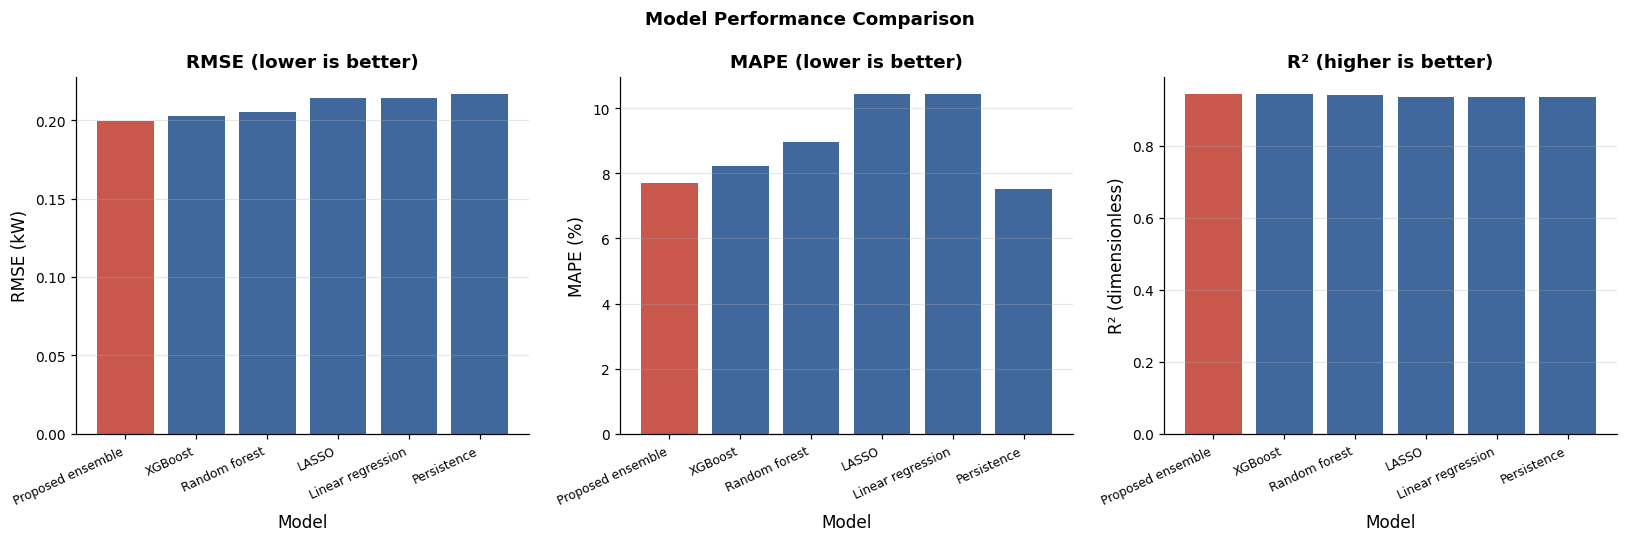

In [19]:
# Comparison of forecast accuracy across models
# MASE is included for every model evaluated at one-minute resolution. It is
# left blank for the ARIMA model, which operates on hourly aggregates and
# therefore has no comparable one-minute seasonal-naive denominator.
metric_keys = ['MAE', 'RMSE', 'R2', 'MAPE', 'sMAPE', 'DA', 'MASE']
_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})

rows = []
for name, v in results.items():
    if name in _alias:  
        continue
    row = {'Model': name}
    for k in metric_keys:
        row[k] = v['metrics'].get(k, np.nan)
    rows.append(row)

metrics_df = (
    pd.DataFrame(rows)
    .sort_values('RMSE')
    .reset_index(drop=True)
)
print("\n--- Model comparison ---")
print(metrics_df.round(5).to_string(index=False))
metrics_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)


# Comparison of the principal models on three complementary criteria.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
key_models = ['Persistence', 'LinearRegression', 'LASSO', 'RandomForest',
              'XGBoost', 'HybridStack (Proposed)']
plot_df    = metrics_df[metrics_df['Model'].isin(key_models)].copy()

for ax, metric, title, ylab in zip(
    axes,
    ['RMSE', 'MAPE', 'R2'],
    ['RMSE (lower is better)', 'MAPE (lower is better)', 'R² (higher is better)'],
    ['RMSE (kW)', 'MAPE (%)', 'R² (dimensionless)'],
):
    bars = ax.bar(
        range(len(plot_df)),
        plot_df[metric].values,
        color=[PALETTE['secondary'] if m == 'HybridStack (Proposed)' else PALETTE['primary']
               for m in plot_df['Model']],
        alpha=0.85,
    )
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(
        [m.replace('LinearRegression', 'Linear regression')
          .replace('RandomForest', 'Random forest')
          .replace('HybridStack (Proposed)', 'Proposed ensemble')
          for m in plot_df['Model']],
        rotation=25, ha='right', fontsize=8
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylab)
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig_pub('model_comparison_chart')
plt.show()


In [20]:
# Test of equal predictive accuracy


def diebold_mariano(y_true, pred_a, pred_b, h=1, power=2):

    y_true = np.asarray(y_true, dtype='float64')
    e_a = np.abs(y_true - np.asarray(pred_a, dtype='float64'))**power
    e_b = np.abs(y_true - np.asarray(pred_b, dtype='float64'))**power
    d   = e_a - e_b
    n   = len(d)
    dbar = float(d.mean())
    dc   = d - dbar
    L = max(h - 1, int(round(n ** (1/3))))  # truncation lag
    lrv = float(np.mean(dc**2))
    for l in range(1, L + 1):
        w_l = 1.0 - l / (L + 1)  # Bartlett kernel weight
        lrv += 2.0 * w_l * float(np.mean(dc[l:] * dc[:-l]))
    lrv = max(lrv, 1e-300)
    dm  = dbar / np.sqrt(lrv / n)
    dm *= np.sqrt((n + 1 - 2*h + h*(h - 1)/n) / n)  # small-sample correction
    p   = 2.0 * (1.0 - stats.t.cdf(abs(dm), df=n - 1))
    return float(dm), float(p)

def dm_test_wilcoxon(y_true, y_pred_a, y_pred_b):
    """Wilcoxon signed-rank test on the loss differential."""
    d = (y_true - y_pred_a)**2 - (y_true - y_pred_b)**2
    if np.all(d == 0):
        return np.nan
    _, pval = wilcoxon(d, alternative='two-sided')
    return float(pval)

PROPOSED_KEY = globals().get('PROPOSED_KEY', 'HybridStack (Proposed)')
_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})

dm_rows = []
for name, v in results.items():
    if name in _alias or name in ('ARIMA', PROPOSED_KEY):
        continue
    if len(v['y_pred']) != len(y_pred_hw):
        continue
    dm_stat, dm_p = diebold_mariano(y_test, v['y_pred'], y_pred_hw, h=1)
    wil_p         = dm_test_wilcoxon(y_test, v['y_pred'], y_pred_hw)
    dm_rows.append({
        'Baseline':    name,
        'DM_stat':     round(dm_stat, 3),
        'DM_p_value':  f'{dm_p:.2e}',
        'Wilcoxon_p':  f'{wil_p:.2e}' if np.isfinite(wil_p) else 'n/a',
        'Proposed_better': 'yes' if (dm_stat > 0 and dm_p < 0.05) else 'no',
    })

dm_df = pd.DataFrame(dm_rows)
print(f"\n--- Diebold-Mariano tests against {PROPOSED_KEY} ---")

print(dm_df.to_string(index=False))
dm_df.to_csv(OUTPUT_DIR / 'diebold_mariano_tests.csv', index=False)



--- Diebold-Mariano tests against HybridStack (Proposed) ---
        Baseline  DM_stat DM_p_value Wilcoxon_p Proposed_better
     Persistence   22.385   0.00e+00   0.00e+00             yes
LinearRegression   22.549   0.00e+00   0.00e+00             yes
           LASSO   22.398   0.00e+00   0.00e+00             yes
             KNN   54.779   0.00e+00   0.00e+00             yes
    RandomForest   17.405   0.00e+00   0.00e+00             yes
         XGBoost   13.705   0.00e+00   0.00e+00             yes



--- RMSE by temporal granularity ---
Granularity             Hourly   Daily  Weekly  Monthly  Quarterly
Model                                                             
HybridStack (Proposed)  0.0247  0.0063  0.0024   0.0014     0.0004
KNN                     0.1988  0.1006  0.0836   0.0733     0.0778
LASSO                   0.0284  0.0057  0.0023   0.0020     0.0012
LinearRegression        0.0284  0.0059  0.0026   0.0022     0.0013
RandomForest            0.0249  0.0067  0.0045   0.0046     0.0037
XGBoost                 0.0251  0.0080  0.0043   0.0032     0.0028


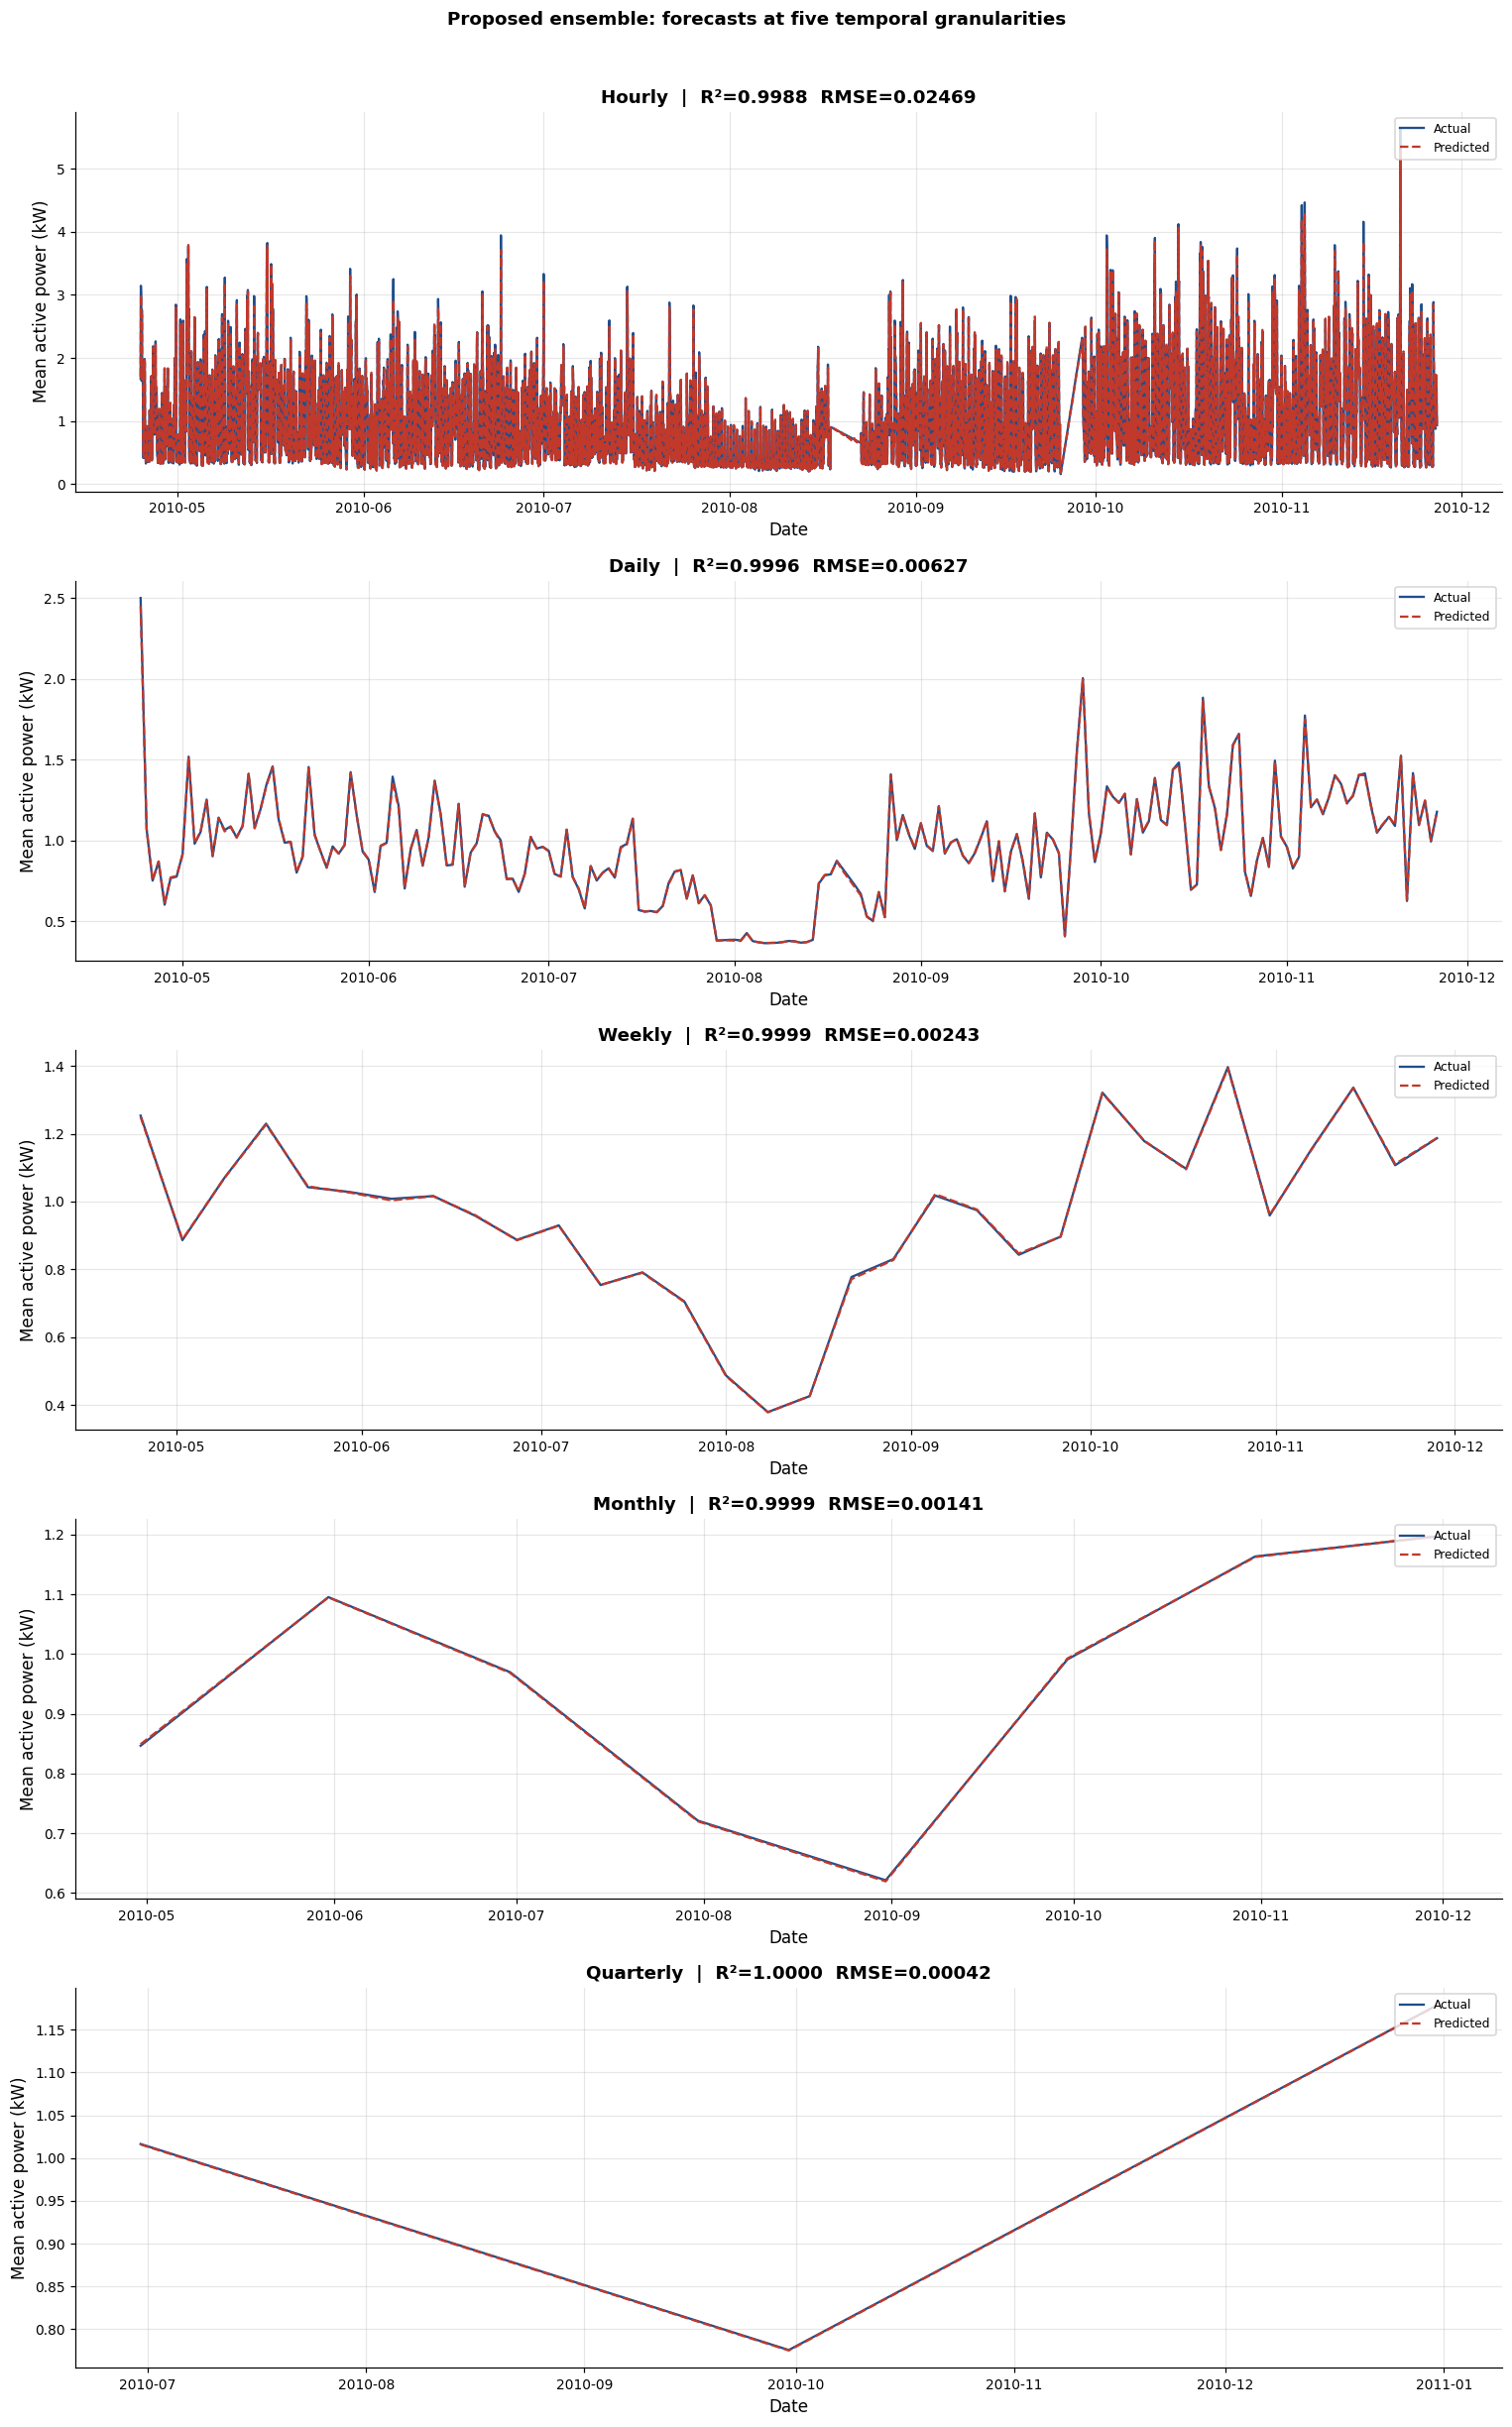

8245

In [21]:
# Multi-granularity evaluation
# The one-minute predictions are averaged to hourly, daily, weekly, monthly and
# quarterly means in order to establish whether the accuracy ordering of the
# models is preserved across temporal scales.

GRANULARITIES = {
    'Hourly':    'h',
    'Daily':     'D',
    'Weekly':    'W',
    'Monthly':   'M',
    'Quarterly': 'Q',
}

def multi_gran_metrics(y_true_arr, y_pred_arr, test_index):
    pred_df = pd.DataFrame(
        {'actual': y_true_arr, 'pred': y_pred_arr}, index=test_index
    )
    rows = []
    for name, freq in GRANULARITIES.items():
        r = pred_df.resample(freq).mean().dropna()
        if len(r) < 2:
            continue
        m = eval_metrics(r['actual'].values, r['pred'].values)
        m['Granularity'] = name
        rows.append(m)
    return pd.DataFrame(rows)

_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})
multi_rows = []
for name, v in results.items():

    if name == 'ARIMA' or name == 'Persistence' or name in _alias:
        continue
    g = multi_gran_metrics(y_test, v['y_pred'], test_df.index)
    g.insert(0, 'Model', name)
    multi_rows.append(g)

multi_df = (
    pd.concat(multi_rows, ignore_index=True)
    .sort_values(['Granularity', 'RMSE'])
)
print("\n--- RMSE by temporal granularity ---")
pivot_rmse = multi_df.pivot_table(
    index='Model', columns='Granularity',
    values='RMSE', aggfunc='first'
)[list(GRANULARITIES.keys())]
print(pivot_rmse.round(4).to_string())
multi_df.to_csv(OUTPUT_DIR / 'multi_granularity_metrics.csv', index=False)

# Forecast plot at each granularity
pred_full = pd.DataFrame(
    {'actual': y_test, 'predicted': y_pred_hw}, index=test_df.index
)
fig, axes = plt.subplots(5, 1, figsize=(14, 22))
for ax, (label, freq) in zip(axes, GRANULARITIES.items()):
    r = pred_full.resample(freq).mean().dropna()
    ax.plot(r.index, r['actual'],    label='Actual',    lw=1.5, color=PALETTE['primary'])
    ax.plot(r.index, r['predicted'], label='Predicted', lw=1.5,
            color=PALETTE['secondary'], ls='--')
    m = eval_metrics(r['actual'].values, r['predicted'].values)
    ax.set_title(
        f"{label}  |  R²={m['R2']:.4f}  RMSE={m['RMSE']:.5f}",
        fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylabel('Mean active power (kW)'); ax.set_xlabel('Date'); ax.grid(alpha=0.3)
plt.suptitle('Proposed ensemble: forecasts at five temporal granularities',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
savefig_pub('multi_granularity_forecasts')
plt.show()
del pred_full; gc.collect()



 5-minute resolution
  Rows (post-FE): 414,477   Train/Val/Test: 290,133/62,172/62,172   Features: 16
  Proposed regime: five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)   (fit 36s)
  Model                 RMSE       R²    MAPE%
  --------------------------------------------
  Seasonal-naive      0.9696  -0.3685    96.18
  RandomForest        0.3366   0.8351    23.99
  XGBoost             0.3386   0.8331    23.73
  Proposed            0.3355   0.8361    22.41   (improves on both references)
  Skill against the seasonal naive: +65.4% reduction in RMSE

 Hourly resolution
  Rows (post-FE): 34,397   Train/Val/Test: 24,077/5,160/5,160   Features: 16
  Proposed regime: five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)   (fit 6s)
  Model                 RMSE       R²    MAPE%
  --------------------------------------------
  Seasonal-naive      0.7467  -0.1314    65.51
  RandomForest        0.4573   0.5757    43.93
  XGBoost             0.4588   0

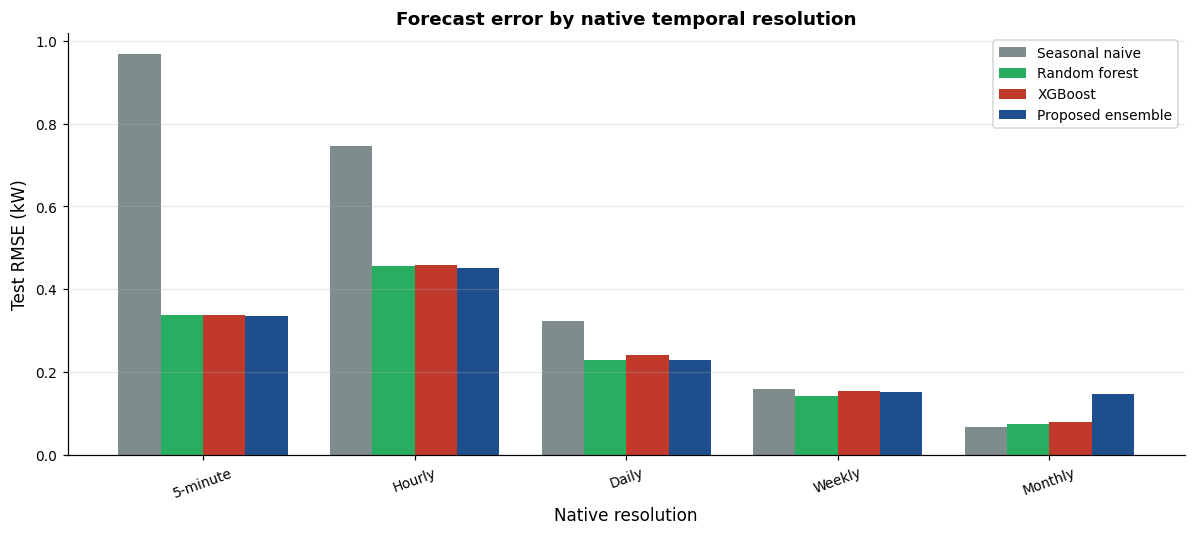

2848

In [22]:
# Forecasting at six native temporal resolutions
# At one-minute resolution the comparison is dominated by persistence, since
# the immediately preceding observation accounts for most of the variance. The
# contribution of the proposed ensemble is therefore examined at coarser native
# resolutions, where calendar and seasonal structure carries more of the signal.
# At each resolution a seasonal-naive reference, a random forest, a gradient-
# boosted model and the proposed ensemble are trained on the same target. The
# complexity of the ensemble is matched to the available sample size, and the
# seasonal-naive reference alone is reported where the sample is too small to
# support a learned model. All features are shifted by at least one step and
# all splits are chronological.

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

# Configuration for each resolution.
RES_SPECS = {
    '5min':    dict(freq='5min', label='5-minute', lags=[1, 3, 6, 12, 288],
                    rolls=[12, 288],  seas=288),  # 288 steps = 1 day
    'hourly':  dict(freq='h',    label='Hourly',   lags=[1, 2, 3, 24, 168],
                    rolls=[24, 168],  seas=24),  # 24 steps = 1 day
    'daily':   dict(freq='D',    label='Daily',    lags=[1, 2, 7, 14, 30],
                    rolls=[7, 30],    seas=7),  # 7 steps = 1 week
    'weekly':  dict(freq='W',    label='Weekly',   lags=[1, 2, 4, 52],
                    rolls=[4, 52],    seas=52),  # 52 steps = 1 year
    'monthly': dict(freq='MS',   label='Monthly',  lags=[1, 2, 3, 12],
                    rolls=[3, 12],    seas=12),  # 12 steps = 1 year
    'yearly':  dict(freq='YS',   label='Yearly',   lags=[1, 2],
                    rolls=[2],        seas=1),
}

# Sample-size thresholds, counted after feature construction and the removal
# of rows with incomplete lag history.
MIN_ROWS_FULL   = 250  
MIN_ROWS_MEDIUM = 120  
MIN_ROWS_SIMPLE = 30   

def _build_res_frame(freq, lags, rolls):
    """Aggregate the target to `freq` and construct features from past values."""
    s = df[TARGET].resample(freq).mean().dropna()
    d = pd.DataFrame({TARGET: s})
    idx = d.index

    # Calendar / seasonal encodings appropriate to the resolution
    if freq in ('5min', 'h'):
        d['hr_sin'] = np.sin(2 * np.pi * idx.hour / 24)
        d['hr_cos'] = np.cos(2 * np.pi * idx.hour / 24)
    if freq in ('5min', 'h', 'D'):
        d['dow_sin'] = np.sin(2 * np.pi * idx.dayofweek / 7)
        d['dow_cos'] = np.cos(2 * np.pi * idx.dayofweek / 7)
    # Annual seasonality is informative at every resolution.
    d['moy_sin'] = np.sin(2 * np.pi * (idx.month - 1) / 12)
    d['moy_cos'] = np.cos(2 * np.pi * (idx.month - 1) / 12)

    # Lags
    for L in lags:
        d[f'lag_{L}'] = d[TARGET].shift(L)

    # Rolling statistics, computed on the shifted series
    sh = d[TARGET].shift(1)
    for w in rolls:
        d[f'rmean_{w}'] = sh.rolling(w, min_periods=1).mean()
        d[f'rstd_{w}']  = sh.rolling(w, min_periods=1).std()

    # First difference
    d['diff1'] = d[TARGET].shift(1) - d[TARGET].shift(2)

    return d.dropna().astype('float32', errors='ignore')

def _blend_predict(bases, meta, Xtr, ytr, Xva, yva, Xte):
 
    Xtr, ytr = np.asarray(Xtr), np.asarray(ytr)
    Xva, yva = np.asarray(Xva), np.asarray(yva)
    Xte = np.asarray(Xte)
    fitted = [clone(est).fit(Xtr, ytr) for _nm, est in bases]
    B_va = np.column_stack([m.predict(Xva) for m in fitted])
    B_te = np.column_stack([m.predict(Xte) for m in fitted])

    meta_fit = clone(meta).fit(B_va, yva)
    blend_va = meta_fit.predict(B_va)
    blend_rmse = float(np.sqrt(np.mean((blend_va - yva) ** 2)))

    base_rmses = [float(np.sqrt(np.mean((B_va[:, j] - yva) ** 2)))
                  for j in range(len(bases))]
    best_j = int(np.argmin(base_rmses))

    def _cal(p_va, p_te):
        a, b = np.linalg.lstsq(np.column_stack([p_va, np.ones_like(p_va)]), yva, rcond=None)[0]
        return a * p_te + b
    if blend_rmse <= base_rmses[best_j]:
        return _cal(blend_va, meta_fit.predict(B_te)), False
    return _cal(B_va[:, best_j], B_te[:, best_j]), True

def _fit_proposed(Xtr, ytr, Xva, yva, Xte, n_rows):
    """Fit the proposed ensemble at a complexity matched to the sample size."""
    nn_ridge = Ridge(alpha=1.0, positive=True)  # non-negative combination weights
    if n_rows >= MIN_ROWS_FULL:
        bases = [
            ('xgb', XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                 tree_method='hist', objective='reg:squarederror',
                                 random_state=RANDOM_STATE, n_jobs=-1)),
            ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                   subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                   min_child_samples=20, random_state=RANDOM_STATE,
                                   n_jobs=-1, verbose=-1)),
            ('cat', CatBoostRegressor(iterations=400, learning_rate=0.05, depth=7,
                                      l2_leaf_reg=3.0, loss_function='RMSE',
                                      random_seed=RANDOM_STATE, verbose=False,
                                      allow_writing_files=False)),
            ('et', ExtraTreesRegressor(n_estimators=200, min_samples_leaf=3,
                                       max_features='sqrt', random_state=RANDOM_STATE,
                                       n_jobs=-1)),
            ('rf', RandomForestRegressor(n_estimators=200, max_depth=14,
                                         min_samples_leaf=3, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
        ]
        base_tag = 'five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)'
    elif n_rows >= MIN_ROWS_MEDIUM:
        bases = [
            ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                 subsample=0.9, reg_lambda=2.0, tree_method='hist',
                                 objective='reg:squarederror',
                                 random_state=RANDOM_STATE, n_jobs=-1)),
            ('et', ExtraTreesRegressor(n_estimators=200, min_samples_leaf=2,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
            ('ridge', Ridge(alpha=1.0)),
            ('rf', RandomForestRegressor(n_estimators=150, max_depth=12,
                                         min_samples_leaf=3, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
        ]
        base_tag = 'four learners (XGBoost, extra trees, ridge, random forest)'
    else:  
        bases = [
            ('ridge', Ridge(alpha=1.0)),
            ('et', ExtraTreesRegressor(n_estimators=150, min_samples_leaf=2,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ]
        base_tag = 'two learners (ridge, extra trees)'

    yp, fell_back = _blend_predict(bases, nn_ridge, Xtr, ytr, Xva, yva, Xte)
    regime = base_tag + (' [fallback to best single learner]' if fell_back else '')
    return yp, regime

def _run_resolution(key):
    spec = RES_SPECS[key]
    print(f'\n{"="*64}\n {spec["label"]} resolution\n{"="*64}')

    d = _build_res_frame(spec['freq'], spec['lags'], spec['rolls'])
    N = len(d)
    if N == 0:
        print('  No data after aggregation: resolution finer than the source.')
        return None

    feats = [c for c in d.columns if c != TARGET]
    tr_e, va_e = int(N * 0.70), int(N * 0.85)
    trd, vad, ted = d.iloc[:tr_e], d.iloc[tr_e:va_e], d.iloc[va_e:]
    print(f'  Rows (post-FE): {N:,}   Train/Val/Test: {len(trd):,}/{len(vad):,}/{len(ted):,}'
          f'   Features: {len(feats)}')

    if len(ted) < 2:
        print(f'  Only {len(ted)} test observation(s); insufficient to evaluate.')
        return None

    ytr = trd[TARGET].to_numpy('float32')
    yte = ted[TARGET].to_numpy('float32')

 
    seas = max(1, min(spec['seas'], len(d) - 1))
    naive_pred = d[TARGET].shift(seas).to_numpy('float32')[va_e:]
    m_naive = eval_metrics(yte, np.nan_to_num(naive_pred, nan=float(ytr.mean())),
                           y_train_ref=ytr, seasonal_period=seas)

    row = {'Resolution': spec['label'], 'N': N, 'N_test': len(ted),
           'Naive_RMSE': m_naive['RMSE']}

    # Where the sample is too small to support a learned model, only the
    # seasonal-naive reference is reported.
    if N < MIN_ROWS_SIMPLE:
        print(f'  {N} rows, below the threshold of {MIN_ROWS_SIMPLE}. ')
        print(f'    Seasonal-naive  RMSE={m_naive["RMSE"]:.4f}  R²={m_naive["R2"]:.4f}')
        row.update({'Regime': 'naive-only', 'RF_RMSE': np.nan, 'XGB_RMSE': np.nan,
                    'Proposed_RMSE': np.nan, 'Proposed_R2': np.nan,
                    'Proposed_MAPE': np.nan, 'beats_base': False})
        return row

    Xtr_raw, Xva_raw, Xte_raw = trd[feats], vad[feats], ted[feats]
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr_raw).astype('float32')
    Xva = sc.transform(Xva_raw).astype('float32')
    Xte = sc.transform(Xte_raw).astype('float32')
    yva = vad[TARGET].to_numpy('float32')

    # Reference learners
    rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=3,
                               max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(Xtr, ytr)
    m_rf = eval_metrics(yte, np.maximum(rf.predict(Xte), 0.0), y_train_ref=ytr,
                        seasonal_period=seas)

    xgb_b = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                         tree_method='hist', objective='reg:squarederror',
                         random_state=RANDOM_STATE, n_jobs=-1)
    xgb_b.fit(Xtr, ytr)
    m_xgb = eval_metrics(yte, np.maximum(xgb_b.predict(Xte), 0.0), y_train_ref=ytr,
                         seasonal_period=seas)

    # Proposed ensemble, at a complexity matched to the sample size
    t0 = time.time()
    yp, regime = _fit_proposed(Xtr, ytr, Xva, yva, Xte, N)
    yp = np.maximum(yp, 0.0)
    m_prop = eval_metrics(yte, yp, y_train_ref=ytr, seasonal_period=seas,
                          compute_ci=(N >= MIN_ROWS_FULL))
    print(f'  Proposed regime: {regime}   (fit {time.time()-t0:.0f}s)')

    beats = (m_prop['RMSE'] < m_rf['RMSE']) and (m_prop['RMSE'] < m_xgb['RMSE'])
    skill = (1 - m_prop['RMSE'] / m_naive['RMSE']) * 100 if m_naive['RMSE'] > 0 else np.nan

    print(f'  {"Model":<16}{"RMSE":>10}{"R²":>9}{"MAPE%":>9}')
    print(f'  {"-"*44}')
    print(f'  {"Seasonal-naive":<16}{m_naive["RMSE"]:>10.4f}{m_naive["R2"]:>9.4f}{m_naive["MAPE"]:>9.2f}')
    print(f'  {"RandomForest":<16}{m_rf["RMSE"]:>10.4f}{m_rf["R2"]:>9.4f}{m_rf["MAPE"]:>9.2f}')
    print(f'  {"XGBoost":<16}{m_xgb["RMSE"]:>10.4f}{m_xgb["R2"]:>9.4f}{m_xgb["MAPE"]:>9.2f}')
    print(f'  {"Proposed":<16}{m_prop["RMSE"]:>10.4f}{m_prop["R2"]:>9.4f}{m_prop["MAPE"]:>9.2f}'
          f'   {"(improves on both references)" if beats else "(does not improve on the references)"}')
    print(f'  Skill against the seasonal naive: {skill:+.1f}% reduction in RMSE')

    row.update({'Regime': regime.split()[0], 'RF_RMSE': m_rf['RMSE'],
                'XGB_RMSE': m_xgb['RMSE'], 'Proposed_RMSE': m_prop['RMSE'],
                'Proposed_R2': m_prop['R2'], 'Proposed_MAPE': m_prop['MAPE'],
                'Naive_skill_pct': skill, 'beats_base': bool(beats)})
    return row


multires_results = {}
for _rk in ['5min', 'hourly', 'daily', 'weekly', 'monthly', 'yearly']:
    try:
        _r = _run_resolution(_rk)
        if _r is not None:
            multires_results[_rk] = _r
    except Exception as _e:
        print(f'  {_rk} resolution failed: {type(_e).__name__}: {_e}')
    gc.collect()

# Summary table
if multires_results:
    mr_summary = pd.DataFrame(list(multires_results.values()))
    cols = ['Resolution', 'N', 'N_test', 'Naive_RMSE', 'RF_RMSE', 'XGB_RMSE',
            'Proposed_RMSE', 'Proposed_R2', 'Proposed_MAPE', 'beats_base']
    cols = [c for c in cols if c in mr_summary.columns]
    print('\n\n--- Summary across native resolutions ---')
    print(mr_summary[cols].round(4).to_string(index=False))
    mr_summary.to_csv(OUTPUT_DIR / 'multiresolution_comparison.csv', index=False)
    print('\nResults written to multiresolution_comparison.csv')



    # RMSE by resolution. The seasonal-naive reference is plotted alongside
    # the learned models, so that the resolutions at which it remains
    # competitive are visible.
    plot_df = mr_summary.dropna(subset=['Proposed_RMSE'])
    if len(plot_df) >= 2:
        fig, ax = plt.subplots(figsize=(11, 5))
        x = np.arange(len(plot_df)); w = 0.2
        ax.bar(x - 1.5*w, plot_df['Naive_RMSE'],    w, label='Seasonal naive',
               color=PALETTE['neutral'])
        ax.bar(x - 0.5*w, plot_df['RF_RMSE'],       w, label='Random forest',
               color=PALETTE['accent'])
        ax.bar(x + 0.5*w, plot_df['XGB_RMSE'],      w, label='XGBoost',
               color=PALETTE['secondary'])
        ax.bar(x + 1.5*w, plot_df['Proposed_RMSE'], w, label='Proposed ensemble',
               color=PALETTE['primary'])
        ax.set_xticks(x); ax.set_xticklabels(plot_df['Resolution'], rotation=20)
        ax.set_ylabel('Test RMSE (kW)')
        ax.set_xlabel('Native resolution')
        ax.set_title('Forecast error by native temporal resolution', fontweight='bold')
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        savefig_pub('multiresolution_rmse')
        plt.show()
else:
    print('No resolution produced a model result.')
gc.collect()
